# Diabetes Prediction using Deep Learning
## Sprint 1 — Data Preparation and Exploratory Analysis

### Introduction

In this project, we work with the **BRFSS 2015** dataset, a large health survey collected by the CDC, in order to predict whether an individual has diabetes based on demographic, behavioral, and health-related indicators.

The original target variable contains three classes:
- `0` = no diabetes
- `1` = prediabetes
- `2` = diabetes

For this project, the target is converted into a binary variable:
- `0` → no diabetes or prediabetes
- `1` → diabetes

The final goal of the project is to build a **deep learning model** capable of predicting the probability of diabetes while maximizing the **ROC AUC** score.

### Our Approach

Our general approach is structured in three stages:

- **Sprint 1:** prepare, understand and clean the data: variable typing, exploratory data analysis, and normalization.
- **Sprint 2:** Start to develop a **deep learning neural network** for binary classification, train it, evaluate it, and analyze its decision threshold.
- **Sprint 3:** improve the NNs architecture, try to manage the class imbalance (if exists), integrate MLOps principles, and add explainability tools.

Because the dataset is tabular of mainly numerical and binary variables, the deep learning approach will be a **feed-forward neural network (Multilayer Perceptron, MLP)**.

Before training such a model, it is essential to prepare the data carefully, ensure reproducibility, and produce normalized inputs suitable for neural networks.

# Sprint 1
## the preprocessing phase

## 1. Imports, configurations, loading and understanding

#### Imports & Configurations

In [1]:
# Maths, data manipulation and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Scikit-learn libraries for data processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted

# Scikit-learn libraries for evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Scikit-learn models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB

from sklearn import set_config
set_config(transform_output="pandas")

# Misc libraries
import random
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")


# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Paths
DATA_DIR = Path("dataset")
OUTPUT_DIR = Path("deliverables")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "diabetes_012_health_indicators_BRFSS2015.csv"

#### Loading

In [2]:
raw_df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {raw_df.shape}")
display(raw_df.head())

Dataset shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


#### Understanding

In [3]:
print("Column names & types:")
display(raw_df.dtypes.to_frame(name="dtype"))

Column names & types:


,dtype
Diabetes_012,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


In [4]:
print("Descriptive statistics:")
display(raw_df.describe(include="all").T)

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


## 2. Typing of variables

Typing step is important for preprocessing and for choosing the correct normalization strategy.

In this dataset, most variables are already encoded numerically, but they do not all represent the same type of information. We distinguish between:

- **Binary variables**: variables taking values such as `0/1`
- **Ordinal or categorical-coded variables**: variables encoded as integers representing levels or categories
- **Quantitative variables**: continuous or count-based numerical variables

This distinction is especially important for deep learning because scaling decisions should be based on the nature of each variable.

In [5]:
# Suggested typing based on initial look on dataset
# for example: columns of 1 or 0 are usually binary variabls
binary_vars = [
    col for col in raw_df.columns
    if raw_df[col].dropna().nunique() <= 2
]

#cols such as Age, Income.. etc
ordinal_or_categorical_vars = [
    col for col in raw_df.columns
    if col in ["GenHlth", "Age", "Education", "Income"]
]

#identifying quantative cols
quantitative_vars = [
    col for col in raw_df.columns
    if col in ["BMI", "MentHlth", "PhysHlth"]
]

variable_types_df = pd.DataFrame({
    "variable": raw_df.columns
})

def assign_variable_type(col):
    if col in binary_vars:
        return "binary"
    elif col in ordinal_or_categorical_vars:
        return "ordinal/categorical-coded"
    elif col in quantitative_vars:
        return "quantitative"
    else:
        return "other numeric"

variable_types_df["type"] = variable_types_df["variable"].apply(assign_variable_type)

display(variable_types_df.sort_values("type"))

,variable,type
10,Veggies,binary
1,HighBP,binary
2,HighChol,binary
3,CholCheck,binary
5,Smoker,binary
6,Stroke,binary
7,HeartDiseaseorAttack,binary
8,PhysActivity,binary
9,Fruits,binary
18,Sex,binary


## 3. Data explaination

Before going further, we will define and explain each variables included in the dataset.

Most of the variables are binary, meaning that 1 = yes and 0 = no.

|Variable|Description|
|-|-|
|**HighBP**| Indicates whether the person has high blood pressure.|
|**HighChol**| Indicates whether the person has elevated cholesterol levels.|
|**CholCheck**| Shows whether the person has had their cholesterol checked within the past five years.|
|**Smoker**| Indicates whether the person has smoked at least 100 cigarettes over their lifetime.|
|**Stroke**| Indicates wether the person ever had a stroke or told they had a stroke.|
|**HeartDiseaseorAttack**| Indicates wether the person has a heart disease (Coronary Heart Disease) or ever had a heart attack (Myocardial Infarction).|
|**Fruits**| Indicates wether the person eats 1 or more fruits per day.|
|**Veggies**| Indicates wether the person eats 1 or more vegetable per day.|
|**HvyAlcoholConsump**| Indicates wether the person drinks more than 14 drinks per week if they are a man or 7 drinks per week if they are a woman.|
|**AnyHealthcare**| Indicates wether the person has any kind of health care coverage, including health insurance, prepaid plans such as HMO (Health Maintenance Organization), etc.|
|**NoDocbcCost**| Indicates wether the person needed to see a doctor in the past 12 months but couldn't because of the cost.|
|**DiffWalk**| Indicates wether the person has serious difficulty walking or climbing stairs.|
|**Sex**| 0 = female, 1 = male.|
|**PhysActivity**| Indicates wether the person has had any physical activity outside their job in the past 30 days.|
|**BMI**| Body Mass Index. A value used to broadly categorize a person based on tissue mass and height. In our data, the minimum recorded is 12 and the maximum is 98. Major adult BMI classifications are: underweight (under 18.5), normal weight (18.5 to 24.9), overweight (25 to 29.9), and obese (30 or more). As BMI score does not take into account the fat percentage in the weight, someone who is very muscled could be categorized as obese. This means that the BMI should be used in correlation with other variables and not as is.|
|**GenHlth**| General Health. A self estimated value between 1 (Excellent) and 5 (Poor).|
|**MentHlth**| Mental Health. Within the past 30 days, how many days does the individual think his mental health has not been good ? |
|**PhysHlth**| Physical health. Within the past 30 days, how many days does the individual think his physical health has not been good ? |
|**Age**| Age category. Separated into 13 five year levels: <br/><br/>- 1 = 18-24 <br/>- 9 = 60-64 <br/>- 13 = 80|
|**Education**| Education level. Scaled from 1 to 6.<br/><br/> 1 = Never attended school or only kindergarten <br/>2 = Grades 1 through 8 (Elementary) <br/>3 = Grades 9 through 11 (Some high school) <br/>4 = Grade 12 or GED (High school graduate) <br/>5 = College 1 year to 3 years (Some college or technical school) <br/>6 = College 4 years or more (College graduate)|
|**Income**| Income scale<br/><br/>1 = less than $10,000<br/>5 = less than $35,000<br/>8 = $75,000 or more|

## 4. Target transformation and separation of variables

In [6]:
raw_df["Diabetes_binary_original"] = raw_df["Diabetes_012"]

# Binary transformation
raw_df["target"] = raw_df["Diabetes_012"].apply(lambda x: 1 if x == 2 else 0)

print("Original target distribution:")
display(raw_df["Diabetes_binary_original"].value_counts().sort_index())
print("---------------------------------------------")

print("Binary target distribution:")
display(raw_df["target"].value_counts().sort_index())
print("---------------------------------------------")

print("Binary target proportions:")
display((raw_df["target"].value_counts(normalize=True) * 100).round(2))

Original target distribution:


Diabetes_binary_original
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

---------------------------------------------
Binary target distribution:


target
0    218334
1     35346
Name: count, dtype: int64

---------------------------------------------
Binary target proportions:


target
0    86.07
1    13.93
Name: proportion, dtype: float64

In [7]:
X = raw_df.drop(columns=["Diabetes_012", "Diabetes_binary_original", "target"], errors="ignore")
y = raw_df["target"]

print("Shape of explanatory variables X:", X.shape)
print("Shape of target y:", y.shape)

Shape of explanatory variables X: (253680, 21)
Shape of target y: (253680,)


### Final transformer

In [8]:
class DiabetesTargetBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, column_name="Diabetes_012", output_column_name="target", drop_original=True):
        self.column_name = column_name
        self.output_column_name = output_column_name
        self.drop_original = drop_original
    
    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        X_copy[self.output_column_name] = X_copy[self.column_name].apply(lambda x: 1 if x == 2 else 0)
        if self.drop_original:
            X_copy = X_copy.drop(self.column_name, axis=1)
        return X_copy

## 5. Splitting the dataset into train, validation, and test sets

- **Training set**: used to fit the neural network
- **Validation set**: used to tune the model and monitor performance during development
- **Test set**: used only at the end for final evaluation

Because the target classes are imbalanced, we use **stratified splitting** in order to preserve the class proportions across all subsets.

In [9]:
# First split: train vs temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

# Second split: validation vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

train_df = X_train.merge(y_train, left_index=True, right_index=True)
val_df = X_val.merge(y_val, left_index=True, right_index=True)
test_df = X_test.merge(y_test, left_index=True, right_index=True)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (177576, 21) (177576,)
Validation shape: (38052, 21) (38052,)
Test shape: (38052, 21) (38052,)


In [10]:
split_distribution = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
}).T

display((split_distribution * 100).round(2))

target,0,1
train,86.07,13.93
validation,86.07,13.93
test,86.07,13.93


### Final transformer

In [11]:
class StratifiedSplitter(BaseEstimator, TransformerMixin):
    def __init__(self, test_size=0.3, val_size=0.5, y_column_name=None, random_state=None):
        self.test_size = test_size
        self.val_size = val_size
        self.y_column_name = y_column_name
        self.random_state = random_state

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        y = X[self.y_column_name] if self.y_column_name else None
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y,
            test_size=self.test_size,
            stratify=y,
            random_state=self.random_state
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            test_size=self.val_size,
            stratify=y_temp,
            random_state=self.random_state
        )
        return (X_train, y_train), (X_val, y_val), (X_test, y_test)

## 6. Cleaning duplicates and handling missing values

- duplicate records
- missing values

In [12]:
duplicate_count = train_df.duplicated().sum()
print("Number of duplicate rows in the full dataset:", duplicate_count)

Number of duplicate rows in the full dataset: 14391


In [13]:
missing_values = raw_df.isnull().sum().sort_values(ascending=False)
missing_values_df = missing_values.to_frame(name="missing_count")
missing_values_df["missing_percent"] = (missing_values_df["missing_count"] / len(raw_df) * 100).round(4)

display(missing_values_df[missing_values_df["missing_count"] > 0])

,missing_count,missing_percent


We have no missing values

In [14]:
# Removing duplicates
clean_df = raw_df.drop_duplicates().copy()

print("Original shape:", raw_df.shape)
print("Shape after duplicate removal:", clean_df.shape)

Original shape: (253680, 24)
Shape after duplicate removal: (229781, 24)


### Final transformer

In [15]:
class DeduplicationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.drop_duplicates()

In [16]:
dedup_transformer = DeduplicationTransformer()
train_df = dedup_transformer.fit_transform(train_df)
val_df = dedup_transformer.transform(val_df)
test_df = dedup_transformer.transform(test_df)

## 7. Quantitative & Qualitative analysis

Quantitative & Qualitative analysis allow us to understand our data, determine which of them are important and why. That will help us to know how to normalize certains data for our future model.

This step is important to avoid bias and performance problem for our future model.

### Binary target distribution after cleaning

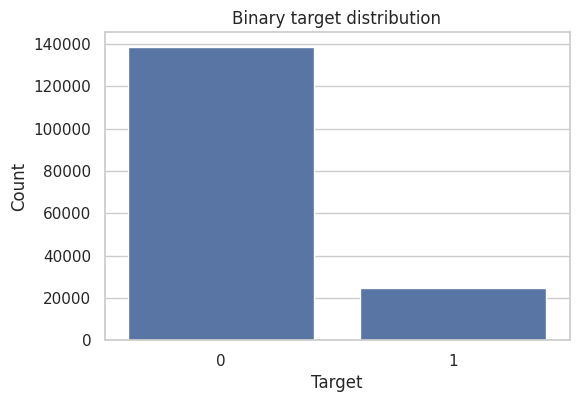

In [17]:
# Visualize the binary target distribution after cleaning

plt.figure(figsize=(6, 4))
sns.countplot(x=(train_df["target"]!=0).astype(int))
plt.title("Binary target distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

Here, we can see the repartition between diabetics and non diabetics persons after cleaning data., That will help us later to determine which data are importants.

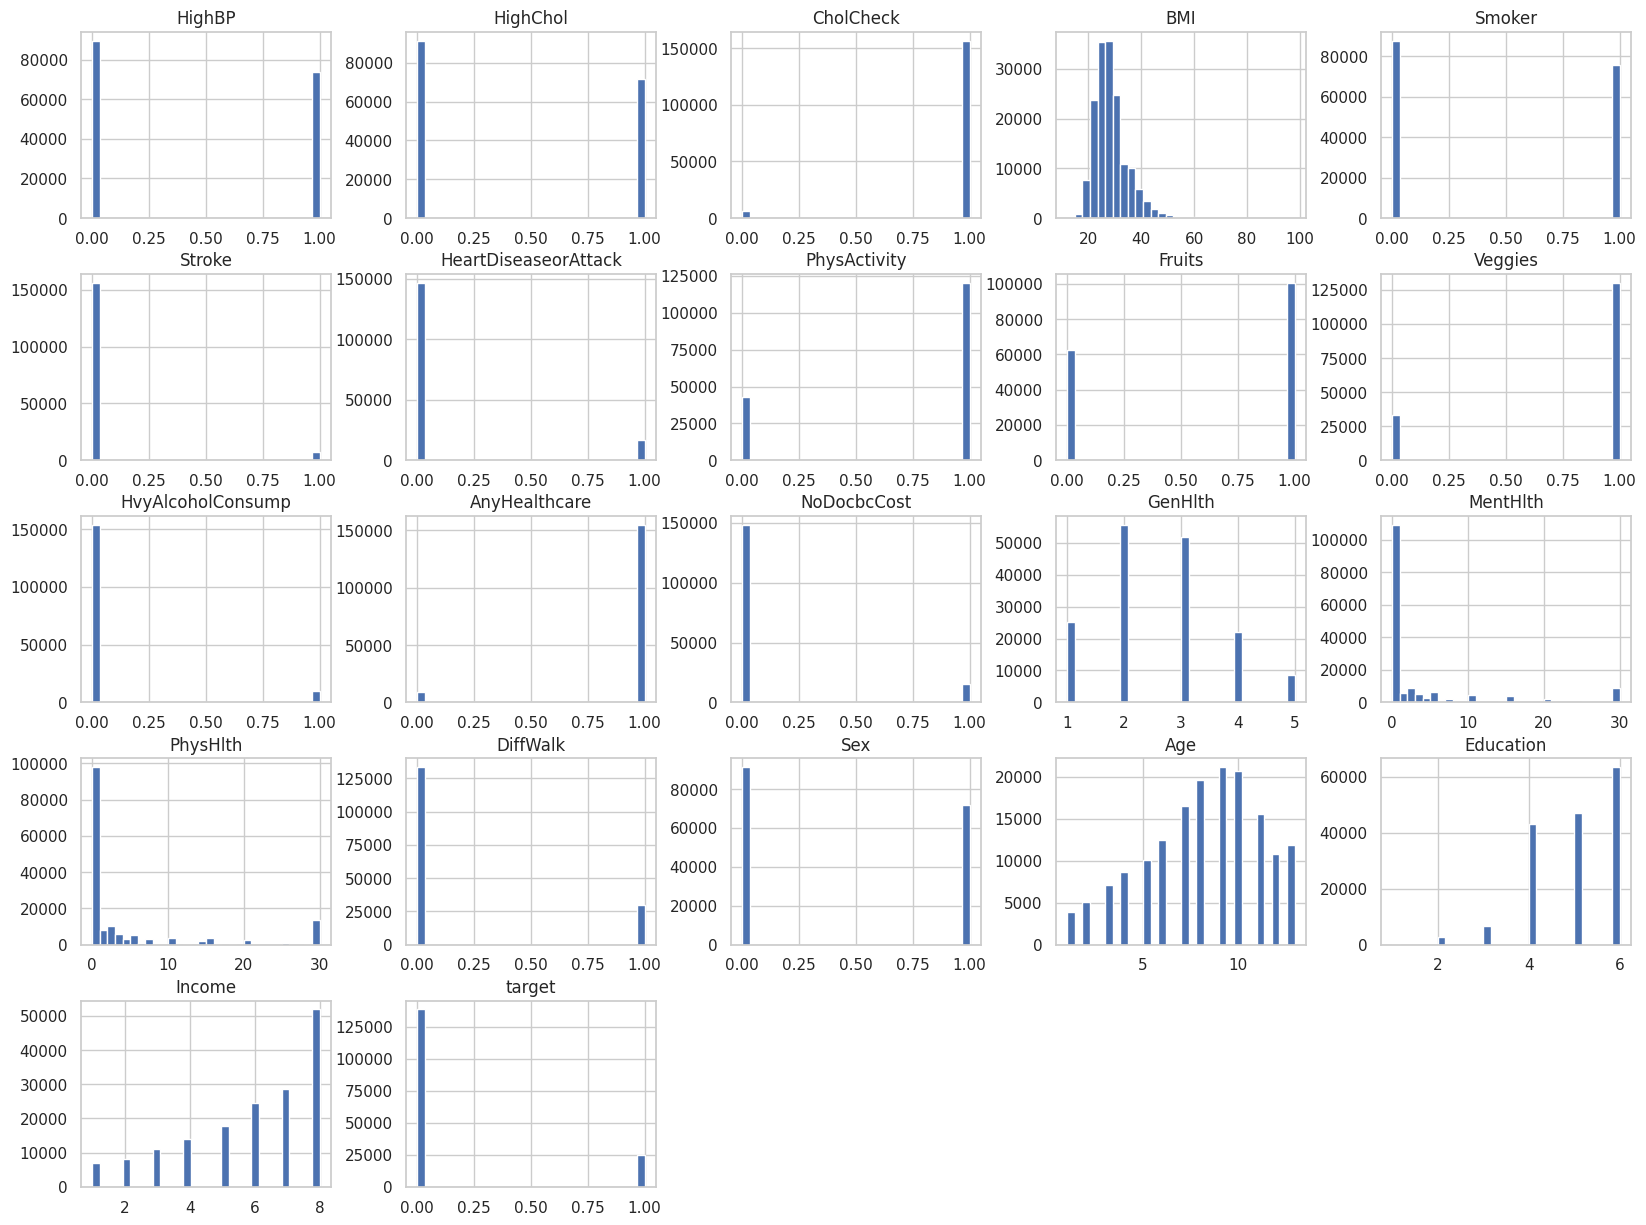

In [18]:
# Visualize the distribution of all qualitative variables for our cleaned set

train_df.hist(figsize=(20, 15), bins=30)
train_df.layout = "tight"

This part allow us to have an overview of all our data, to know which part may cause problems (missing data for example), or need some normalization.

We can also know the statistical summary of our data, allowing us to have a better understanding and to prepare our data analyse for later.

In [19]:
train_df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
HighBP,163185.0,0.451267,0.497621,0.0,0.0,0.0,1.0,1.0
HighChol,163185.0,0.439918,0.496379,0.0,0.0,0.0,1.0,1.0
CholCheck,163185.0,0.959623,0.196844,0.0,1.0,1.0,1.0,1.0
BMI,163185.0,28.638705,6.758458,12.0,24.0,27.0,32.0,98.0
Smoker,163185.0,0.463431,0.498662,0.0,0.0,0.0,1.0,1.0
Stroke,163185.0,0.043846,0.204753,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,163185.0,0.102228,0.302948,0.0,0.0,0.0,0.0,1.0
PhysActivity,163185.0,0.737292,0.440106,0.0,0.0,1.0,1.0,1.0
Fruits,163185.0,0.615835,0.486399,0.0,0.0,1.0,1.0,1.0
Veggies,163185.0,0.797322,0.401996,0.0,1.0,1.0,1.0,1.0


### Distribution of quantitative variables by target class

In [20]:
# Visualize the quantitative summary for our cleaned training set

quantitative_summary = train_df[quantitative_vars].describe().T
display(quantitative_summary)

,count,mean,std,min,25%,50%,75%,max
BMI,163185.0,28.638705,6.758458,12.0,24.0,27.0,32.0,98.0
MentHlth,163185.0,3.466691,7.683939,0.0,0.0,0.0,2.0,30.0
PhysHlth,163185.0,4.611870,9.000360,0.0,0.0,0.0,4.0,30.0


### Boxplot by target class

This kind of graphs allow to visually compare if the non-diabetic and diabetic patients have a significant difference with their numeric variables. That allow to know their capacity to predict the result.

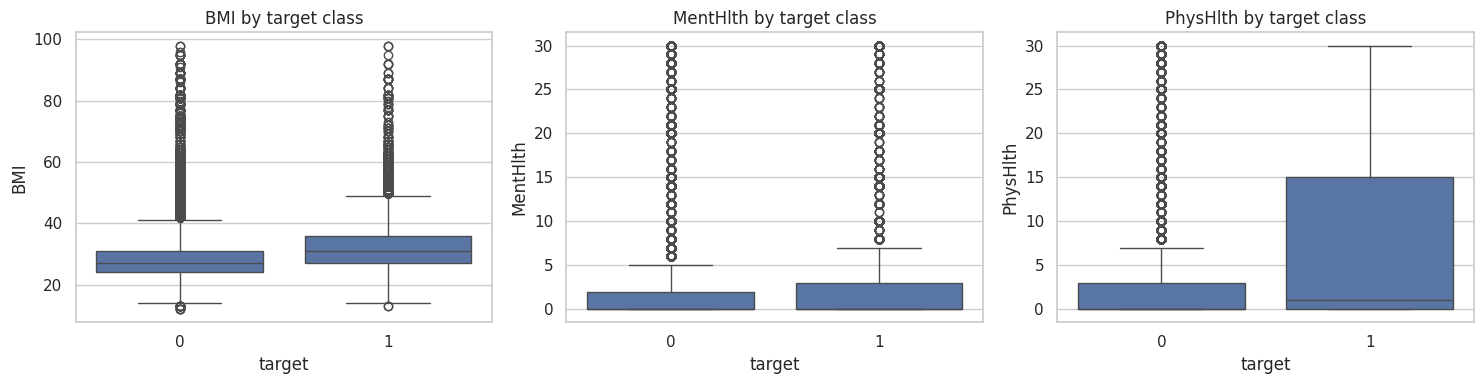

In [21]:
cols = quantitative_vars
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(data=train_df, x="target", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by target class")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

As we can see with the boxplot above, diabetic patient have a BMI a bit superior, but it's not really enough to const a major influence.
We have the same situation with the mentality health, where diabetic person seem to have a bit more problem, but not significantly.
Howerver, the boxplot is really interesting for the third data, because people with diabetes have significantly more physical health problems than those without diabetes.

<span style="color:red"> **Warning : Its important to note that theses data need normalization step because a lot of data are above the upper limit on the boxplot above.**

We have therefore identified physical health data as a key discriminating variable for our project.

### Correlation analysis

With correlation analysis, we can see which variables appear to be correlated with one another. The idea is to be able to determine whether certain data might be important to take into account later on.

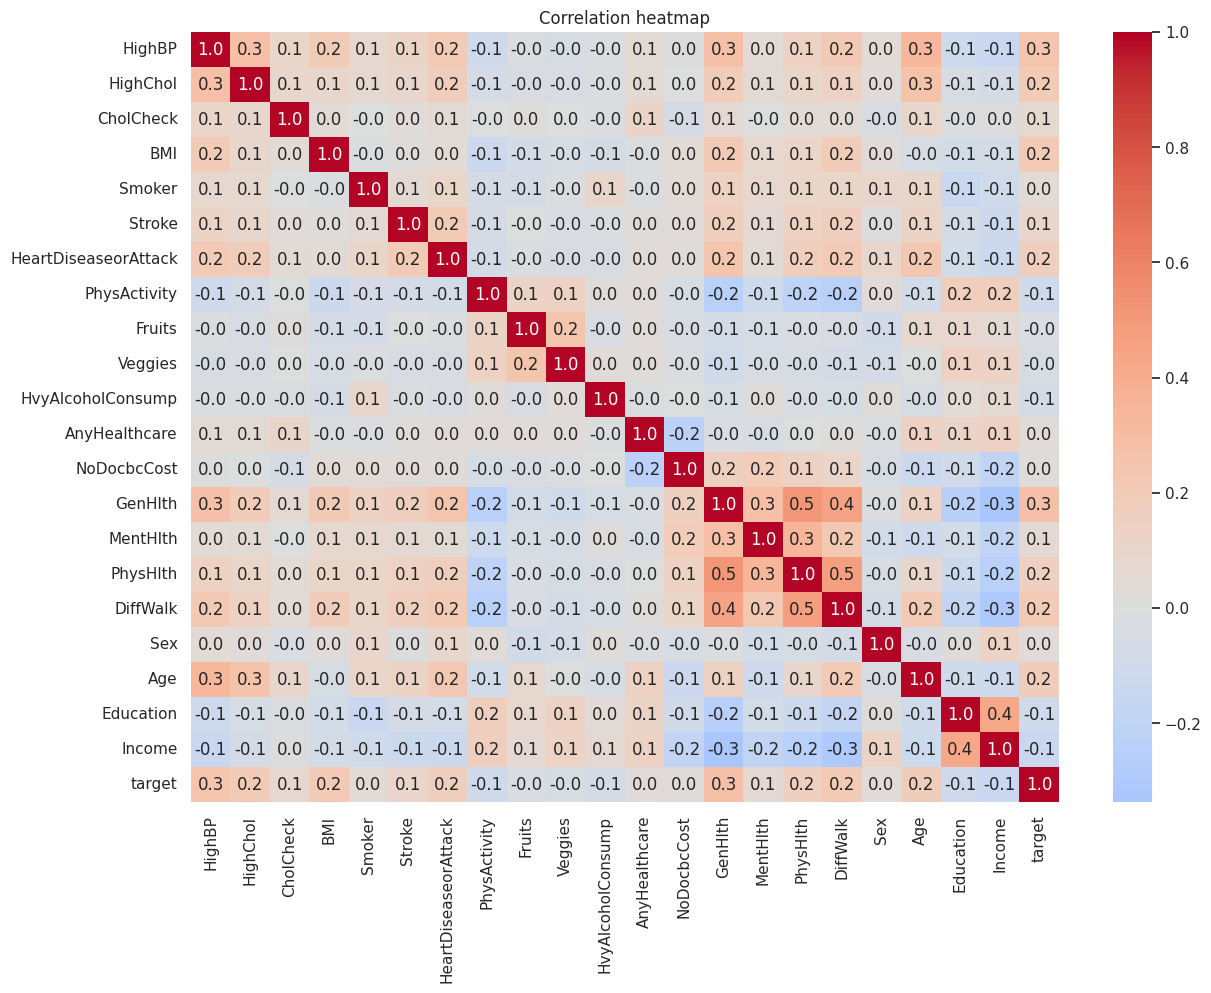

In [22]:
plt.figure(figsize=(14, 10))
corr_matrix = train_df.corr(numeric_only=True)
result = corr_matrix["target"].drop("target").sort_values(ascending=False)
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=True, fmt=".1f")
plt.title("Correlation heatmap")
plt.show()

In this correlation matrix, the most interesting part in our case is the bottom row ‘target’ in conjunction with each column.
The data points with a strong correlation are:
- Correlations close to 1, as these indicate a link between the relevant data points.
- Negative correlations, as these indicate an inverse relationship (for example, the “Income” data seems to suggest that the higher a person’s salary, the lower their risk of diabetes).

Following this principle, we can see that some data points have a correlation close to 0. They are therefore not necessarily very useful for our model and may be removed at a later step according to other analysis. 

### Causality analysis

We considere a correlation treshold of 0.42, and for each case where two values have a correlation above this treshold, we will analyse the causality between them.

In [23]:
# Extract all correlations > 0.42 from the full correlation matrix
# Flatten the correlation matrix and filter for values > 0.5 (excluding diagonal)
result_matrix = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        
        if abs(corr_value) > 0.44:
            result_matrix.append({
                "Variable 1": var1,
                "Variable 2": var2,
                "Correlation": corr_value
            })

# Convert to DataFrame and display
result_df = pd.DataFrame(result_matrix).sort_values("Correlation", ascending=False, key=abs)
display(result_df)

,Variable 1,Variable 2,Correlation
0,GenHlth,PhysHlth,0.517624
2,PhysHlth,DiffWalk,0.468267
1,GenHlth,DiffWalk,0.447389


As far as we can see, we have a few variables with a correlation above 0.44, and among these variables, we can see that ‘DiffWalk’ is at least somewhat linked to the two most highly correlated variables, namely “GenHlth” and ‘PhysHlth’. We can therefore consider that ‘DiffWalk’ is not of great importance in our dataset, but at this stage of the project, we have decided to retain this variable in the dataset for testing purposes.

Now, the aim is to understand why certain variables influence diabetes, and to try to identify patterns and relationships between the values we have.
Carrying out this stage of qualitative analysis enables us to ensure the quality of our data for our future model.

For our project, we have selected certain qualitative data that we consider relevant, such as:
- HighBP
- HighChol
- Smoker
- Stroke
- HeartDiseaseorAttack
- PhysActivity
- Fruits
- Veggies
- HvyAlcoholConsump
- DiffWalk

We chose this data because it cannot be quantified.

In [24]:
# Visualize the distribution of all qualitative variables for our cleaned set
selected_qualitative_vars = [
    col for col in ["HighBP", "HighChol", "Smoker", "Stroke", "HeartDiseaseorAttack",
                    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "DiffWalk"]
    if col in clean_df.columns
]

selected_qualitative_vars

['HighBP',
 'HighChol',
 'Smoker',
 'Stroke',
 'HeartDiseaseorAttack',
 'PhysActivity',
 'Fruits',
 'Veggies',
 'HvyAlcoholConsump',
 'DiffWalk']

Feature                        Ratio of target=1              Ratio of target=0              Total Count                   
------------------------------------------------------------------------------------------------------------------------
HighBP                         0.2519                         0.0677                         163185                        
HighChol                       0.2303                         0.0884                         163185                        
Smoker                         0.1696                         0.1346                         163185                        
Stroke                         0.3182                         0.1431                         163185                        
HeartDiseaseorAttack           0.3323                         0.1302                         163185                        
PhysActivity                   0.1288                         0.2127                         163185                        
Fruits     

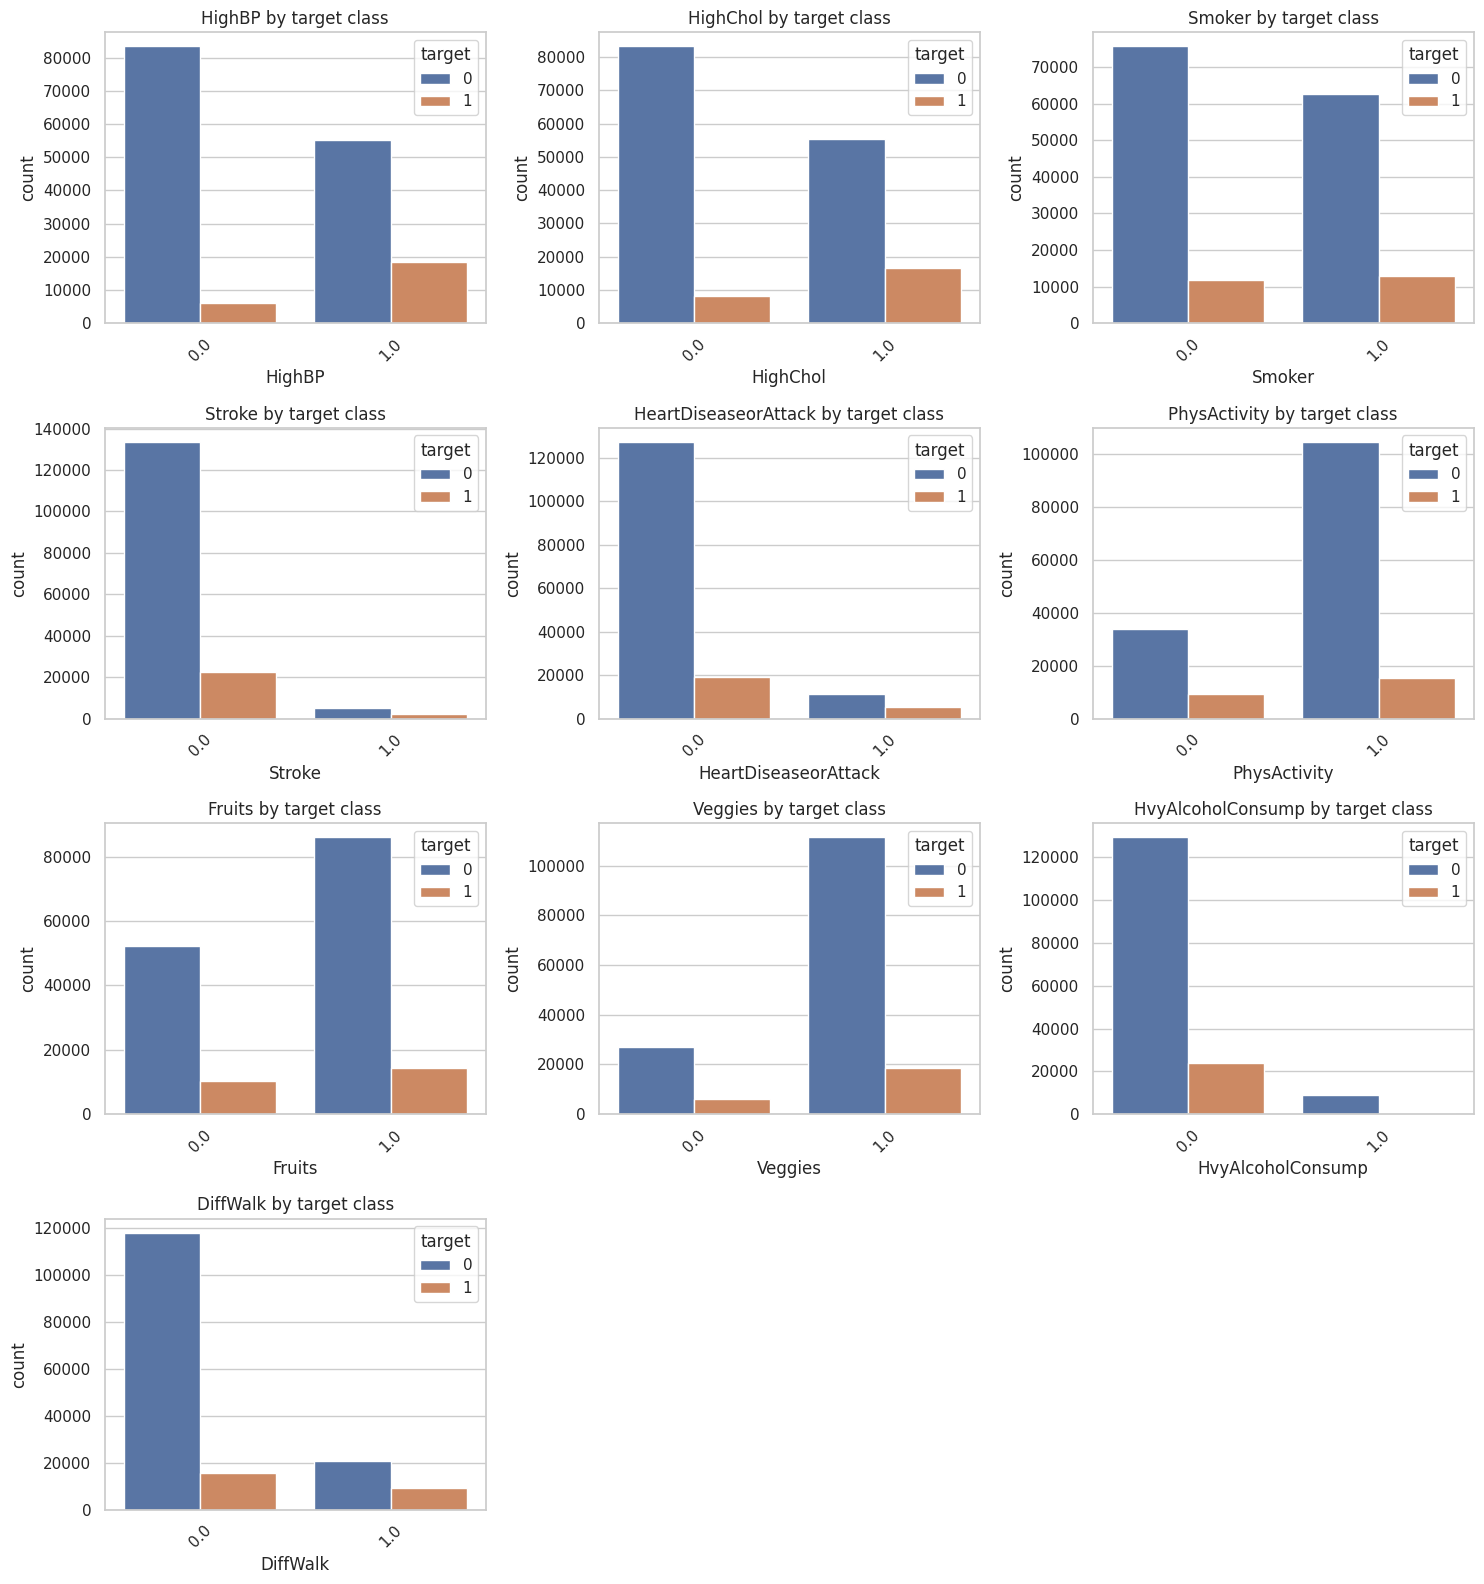

In [25]:
# Visualize the distribution of selected qualitative variables by target class

cols = selected_qualitative_vars
n_cols = 3  # number of plots per row
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()  # make indexing easier

print(f"{'Feature':<30} {'Ratio of target=1':<30} {'Ratio of target=0':<30} {'Total Count':<30}")
print("-" * 120)
for i, col in enumerate(cols):
    sns.countplot(data=train_df, x=col, hue="target", ax=axes[i])
    axes[i].set_title(f"{col} by target class")
    axes[i].tick_params(axis='x', rotation=45)
    ratio_variable_target = train_df.groupby(col)["target"].mean()
    print(f"{col:<30} {ratio_variable_target.get(1, 0):<30.4f} {ratio_variable_target.get(0, 0):<30.4f} {train_df[col].value_counts().sum():<30}")

# remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

This diagram allows us to observe the impact of our qualitative variables on our target, that is to say, to see to what extent each variable affects diabetes in people in general.

Let’s take an example with HighBP representing high blood pressure in the data population:
- target 0 = Non-diabetic
- target 1 = diabetic

We can see that the section of the population without high blood pressure (blue bar) has a very small number of people with diabetes (orange bar).
Conversely, the portion of the population with high blood pressure is smaller (blue bar), but the number of people with diabetes is much higher (orange bar). Thus, a person with high blood pressure is more likely to have diabetes.

It is also possible to verify this by calculating the ratio between the variable in question and the target, and as we can see, the ratio of people with diabetes when a person does not have high blood pressure is 0.07, and when a person has high blood pressure, it is 0.25.

We can therefore conclude that this HighBP variable has a significant impact on whether a patient is diabetic or not.

## 8. Selection and implementation of a normalization method

### Importance of normalization

In this section, we will perform normalization of data in our dataset. Normalizing data will improve our prediction model by preventing (offloading) our model from trying to make different scale variables together to make the model only focus on making correlations between our input variables and the output.

We can only normalize variable that have a spreads on wide range of values (typically intervals bigger than 5), so we filter our dataset to only look at the columns to normalize (filter out `binary_vars` columns)

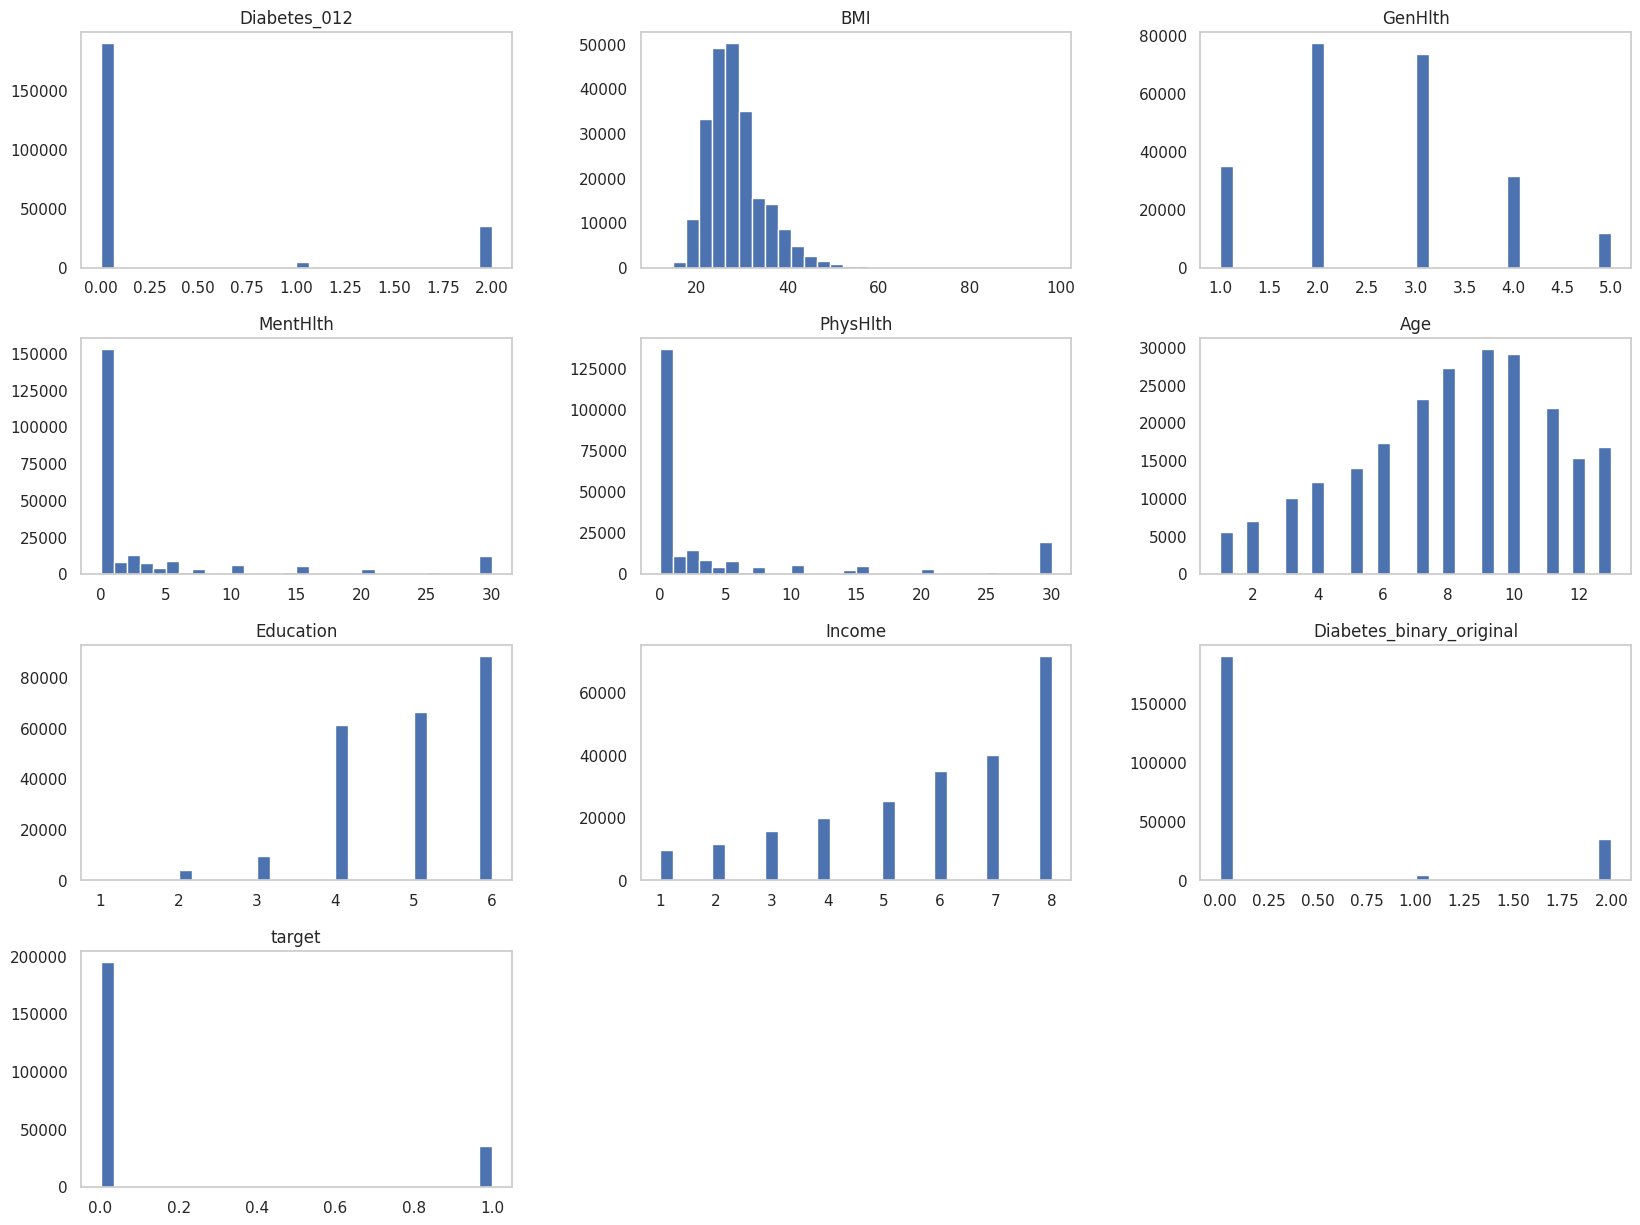

In [26]:
clean_df\
    .drop(binary_vars, axis=1)\
    .hist(figsize=(20,15), bins=30, grid=False)

plt.show()

### Normalization applicability analysis

Now that we have filtered out non-normalizable data, we can realize per feature analysis on the applicability of normalization and, in case we do, which normalization technique we should use among the following list:
- Standardization: $ Z = \frac{X - µ}{\sigma} $ with $µ$ the mean of $X$ and $\sigma$ the standard deviation of $X$
- Min-Max scaling: $ Z = \frac{X - \min(X)}{\max(X) - \min(X)} $ with $\min(X)$ the smallest value of $X$ and $\max(X)$ the biggest value of $X$
- Log transform: $ Z = \log(X) $
- Square root transform: $ Z = \sqrt{X} $

In [27]:
# Log transformer
class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        for col in X.columns:
            X_copy[col] = np.log(X_copy[col] + 1e-7)
        return X_copy

In [28]:
# Square root transformer
class SqrtTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        for col in X.columns:
            X_copy[col] = np.sqrt(X_copy[col])
        return X_copy

To verify that the transformations we apply improve model performance, we will use 4 simpler models, quicker to run, and exploit their metrics before and after preprocessing to determine if the new performance metrics are better than the older ones. We will use the following models:
- Random Forest
- SVC
- KNN
- Naive Bayes (Bernoulli)

In [29]:
class PreprocessingEvaluator():
    def __init__(self, X, y, transformer, column_transformed, verbose=False):
        self.X = X
        self.y = y
        self.transformer = transformer
        self.column_transformed = column_transformed
        self.verbose = verbose
    
    def _run_model(self, model, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        return predictions, y_test

    def _calc_metrics(self, X, y):
        metrics = {}
        for model_name, model in [("Random Forest", RandomForestClassifier(random_state=SEED)),
                                      ("SVM", SVC(random_state=SEED)),
                                      ("KNN", KNeighborsClassifier()),
                                      ("Naive Bayes", BernoulliNB())]:
            if self.verbose:
                print(f"Running {model_name}...", sep=" ")
            predictions, y_test = self._run_model(model, X, y)
            metrics[model_name] = {
                "accuracy": accuracy_score(y_test, predictions),
                "precision": precision_score(y_test, predictions),
                "recall": recall_score(y_test, predictions),
                "f1_score": f1_score(y_test, predictions)
            }
        return metrics

    def evaluate(self):
        if self.verbose:
            print("transforming dataset...")
        new_X = self.X.copy()
        new_X[self.column_transformed] = self.transformer.transform(self.X[[self.column_transformed]])
        if self.verbose:
            print("Evaluating old dataset...", sep=" ")
        self.old_metrics = self._calc_metrics(self.X, self.y)
        if self.verbose:
            print("Evaluating new dataset...", sep=" ")
        self.new_metrics = self._calc_metrics(new_X, self.y)
        return self.old_metrics, self.new_metrics
    
    def display_comparison(self):
        print(f"{'Model':<20} {'Metric':<15} {'Before':<15} {'After':<15} {'Gap':<15}")
        print("=" * 80)
        for model_name in self.old_metrics.keys():
            print("-" * 80)
            for metric_name in self.old_metrics[model_name].keys():
                old_value = self.old_metrics[model_name][metric_name]
                new_value = self.new_metrics[model_name][metric_name]
                gap = new_value - old_value
                print(f"{model_name:<20} {metric_name:<15} {old_value:<15.4f} {new_value:<15.4f} {gap:<15.4f}")

#### BMI

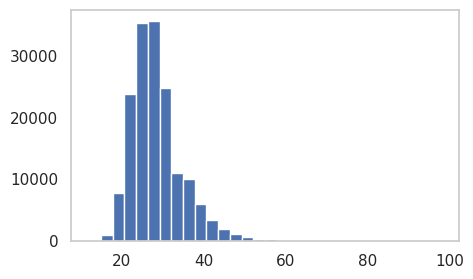

In [30]:
# Graph reminder
train_df["BMI"].hist(figsize=(5,3), bins=30, grid=False)
plt.show()

The data range of the BMI feature is on $ [0;100] $ which is too wide and requires to be normalized into a smaller range. We can also see on the graph that the data has a tail heavy distribution (right skewed) which needs to be centralized for model performance.

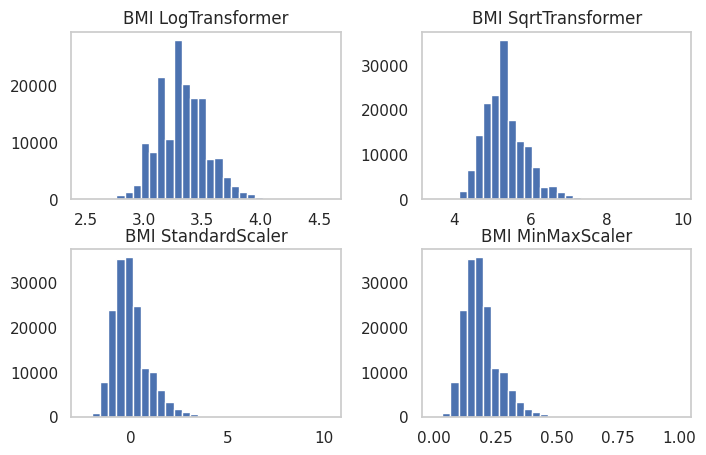

In [31]:
feature = "BMI"
bmi_transformed = pd.DataFrame({
    f"{feature} {LogTransformer().__class__.__name__}": LogTransformer().fit_transform(train_df[[feature]]).squeeze(),
    f"{feature} {SqrtTransformer().__class__.__name__}": SqrtTransformer().fit_transform(train_df[[feature]]).squeeze(),
    f"{feature} {StandardScaler().__class__.__name__}": StandardScaler().fit_transform(train_df[[feature]]).squeeze(),
    f"{feature} {MinMaxScaler().__class__.__name__}": MinMaxScaler().fit_transform(train_df[[feature]]).squeeze()
})

bmi_transformed.hist(figsize=(8,5), bins=30, grid=False)
plt.show()

By graphic lecture, we can see that the `LogTransformer` gives the distribution that is the closest, amongst others, to a gaussian distribution but it's range, $[2.5;4.5]$ is not ideal as contrary to the `MinMaxScaler` which gives the best range $[0:1]$. Maybe we can combine those 2 transformations to fix the distribution then the range.

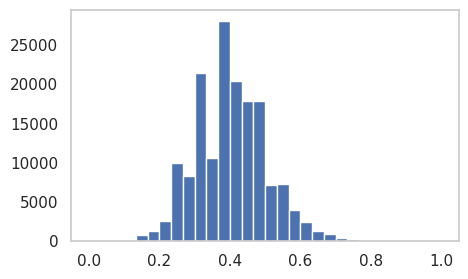

In [32]:
log_minmax_transformer = Pipeline([
    ("log", LogTransformer()),
    ("minmax", MinMaxScaler())
])

log_minmax_transformer.fit_transform(train_df[["BMI"]]).squeeze().hist(figsize=(5,3), bins=30, grid=False)
plt.show()

The `MinMaxScaler` applied after the `LogTransformer` effectively fix the value range $[0;1]$ while keeping the correction from `LogTransformer`, we will keep this transformation for the "BMI" feature.

Now that we defined a theoritical transformer, we will run the validation step to see if it improves the model output.

In [33]:
log_minmax_transformer = Pipeline([
    ("log", LogTransformer()),
    ("minmax", MinMaxScaler())
])

log_minmax_transformer.fit(train_df[["BMI"]])

evaluator = PreprocessingEvaluator(
    X=val_df.drop("target", axis=1),
    y=val_df["target"],
    transformer=log_minmax_transformer,
    column_transformed="BMI",
    verbose=True
)

evaluator.evaluate()
evaluator.display_comparison()

transforming dataset...
Evaluating old dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Evaluating new dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Model                Metric          Before          After           Gap            
--------------------------------------------------------------------------------
Random Forest        accuracy        0.8568          0.8557          -0.0011        
Random Forest        precision       0.4915          0.4790          -0.0126        
Random Forest        recall          0.1381          0.1410          0.0029         
Random Forest        f1_score        0.2156          0.2178          0.0022         
--------------------------------------------------------------------------------
SVM                  accuracy        0.8575          0.8575          0.0000         
SVM                  precision       0.0000          0.0000          0.0000         
SVM        

By looking at this new table, this transformer would reduce the model performance if used, so we will not be using it.

#### General Health (GenHlth)

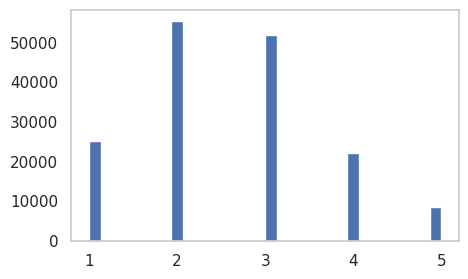

In [34]:
# Graph reminder
train_df["GenHlth"].hist(figsize=(5,3), bins=30, grid=False)
plt.show()

When looking at the data distribution graph for the general health, we can see that the value are in the range $[1;5]$ which is a good length but might be improved by shifting the range closer to 0. Also we can see that we are very close to a gaussian distribution.

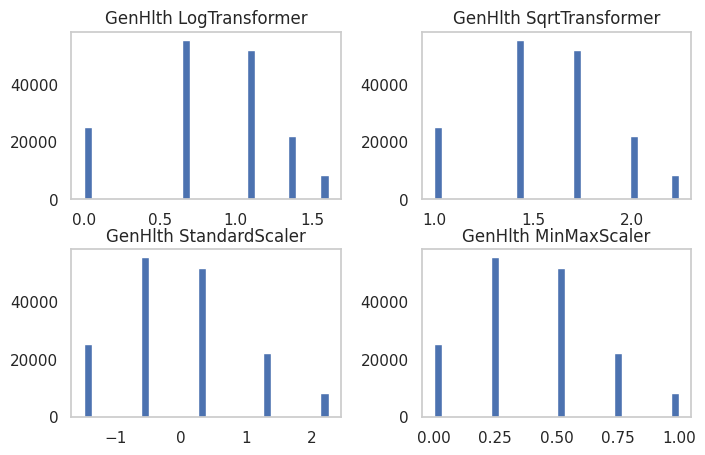

In [35]:
feature = "GenHlth"
gen_hlth_transformed = pd.DataFrame({
    f"{feature} {LogTransformer.__name__}": LogTransformer().fit_transform(train_df[[feature]]).squeeze(),
    f"{feature} {SqrtTransformer.__name__}": SqrtTransformer().fit_transform(train_df[[feature]]).squeeze(),
    f"{feature} {StandardScaler.__name__}": StandardScaler().fit_transform(train_df[[feature]]).squeeze(),
    f"{feature} {MinMaxScaler.__name__}": MinMaxScaler().fit_transform(train_df[[feature]]).squeeze()
})

gen_hlth_transformed.hist(figsize=(8,5), bins=30, grid=False)
plt.show()

We can see than `LogTransformer` and `SqrtTransformer` help with changing the distribution to a gaussian one, but they create a gap in the data which is not great. The `StandardScaler` and `MinMaxScaler` do a good job at shifting the range closer to 0. As explained in the details about ordinal variables, the general health have opposite meaning before and after the middle value, 3, this means that the `StandardScaler` better represents the meaning of this variable.

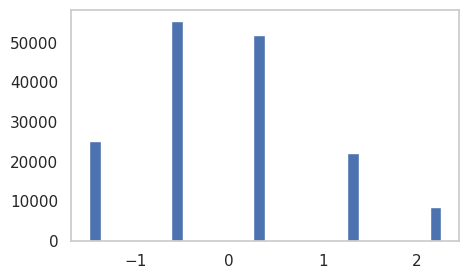

In [36]:
StandardScaler().fit_transform(train_df[["GenHlth"]]).squeeze().hist(figsize=(5,3), bins=30, grid=False)
plt.show()

Now that we defined a theoritical transformer, we will run the validation step to see if it improves the model output.

In [37]:
temp_transformer = StandardScaler()
temp_transformer.fit(train_df[["GenHlth"]])

evaluator = PreprocessingEvaluator(
    X=val_df.drop("target", axis=1),
    y=val_df["target"],
    transformer=temp_transformer,
    column_transformed="GenHlth",
    verbose=True
)

evaluator.evaluate()
evaluator.display_comparison()

transforming dataset...
Evaluating old dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Evaluating new dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Model                Metric          Before          After           Gap            
--------------------------------------------------------------------------------
Random Forest        accuracy        0.8568          0.8568          0.0000         
Random Forest        precision       0.4915          0.4915          0.0000         
Random Forest        recall          0.1381          0.1381          0.0000         
Random Forest        f1_score        0.2156          0.2156          0.0000         
--------------------------------------------------------------------------------
SVM                  accuracy        0.8575          0.8575          0.0000         
SVM                  precision       0.0000          0.0000          0.0000         
SVM        

Most of the metrics shows model improvement, so we will keep this transformation for this column

#### Mental Health (MentHlth)

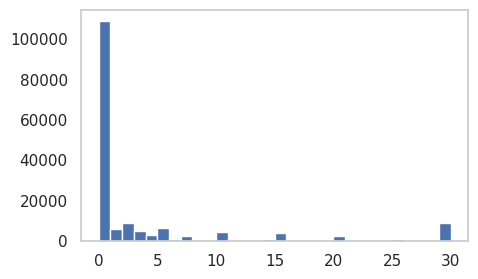

In [38]:
# Graph reminder
train_df["MentHlth"].hist(figsize=(5,3), bins=30, grid=False)
plt.show()

We can see on this graph that the distribution range is $[0;30]$. We also see that most of the value in this column is concentrated on 0, we will draw a box plot diagram to have better look of the quantity of extreme values and how extreme they are.

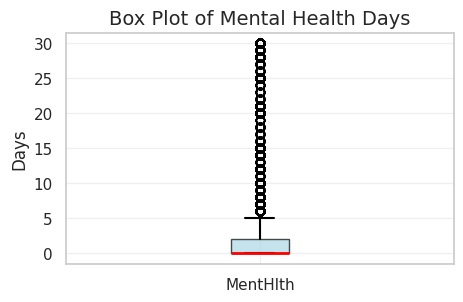

MentHlth Statistics:

Min        Q1 (25%)     Median (50%)    Q3 (75%)     Max        Mean       Std Dev   
------------------------------------------------------------------------------------------
0.0        0.0          0.0             2.0          30.0       3.47       7.68      


In [39]:
# Box plot for MentHlth
fig, ax = plt.subplots(figsize=(5, 3))
ax.boxplot(train_df["MentHlth"], vert=True, patch_artist=True, 
           boxprops=dict(facecolor='lightblue', alpha=0.7),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5))
ax.set_ylabel('Days', fontsize=12)
ax.set_title('Box Plot of Mental Health Days', fontsize=14)
ax.set_xticklabels(['MentHlth'])
ax.grid(True, alpha=0.3)
plt.show()

# Print statistics
print("MentHlth Statistics:\n")
print(f"{'Min':<10} {'Q1 (25%)':<12} {'Median (50%)':<15} {'Q3 (75%)':<12} {'Max':<10} {'Mean':<10} {'Std Dev':<10}")
print("-" * 90)
print(f"{train_df['MentHlth'].min():<10} {train_df['MentHlth'].quantile(0.25):<12} {train_df['MentHlth'].median():<15} {train_df['MentHlth'].quantile(0.75):<12} {train_df['MentHlth'].max():<10} {train_df['MentHlth'].mean():<10.2f} {train_df['MentHlth'].std():<10.2f}")

From this new graph, we can clearly see that we have a lot of extreme values. Those extreme values can have an impact on model performance, so we can clamp the values in this column to not be above 5, 10 or 15 if we want to not transform the dataset too much.

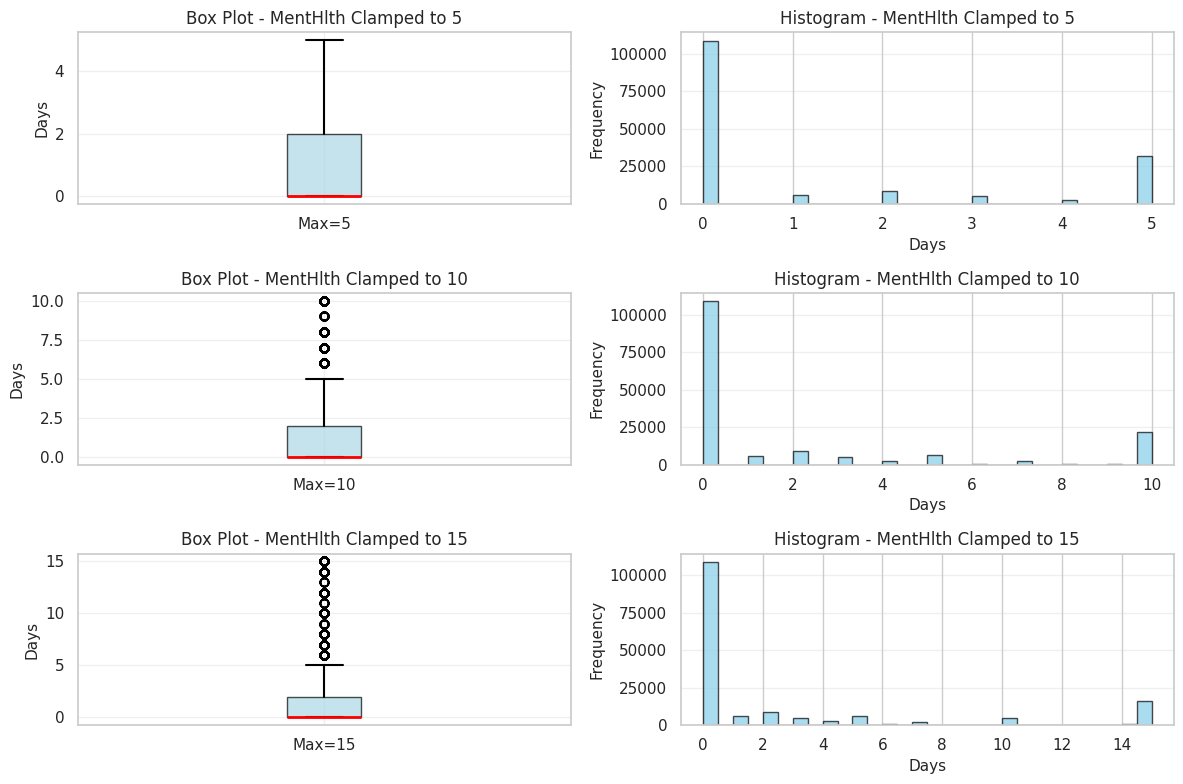

MentHlth Statistics for Each Maximum:

Max Value  Min        Q1 (25%)     Median (50%)    Q3 (75%)     Max        Mean       Std Dev   
------------------------------------------------------------------------------------------
5          0.0        0.0          0.0             2.0          5.0        1.27       2.01      
10         0.0        0.0          0.0             2.0          10.0       1.99       3.51      
15         0.0        0.0          0.0             2.0          15.0       2.51       4.80      


In [40]:
maximums = [5, 10, 15]

# Create box plots and histograms for each maximum value
fig, axes = plt.subplots(len(maximums), 2, figsize=(12, 8))

clamped_data = []
for idx, max_val in enumerate(maximums):
    # Clamp values to the maximum
    clamped = train_df["MentHlth"].clip(upper=max_val)
    clamped_data.append(clamped)
    
    # Create box plot
    ax_box = axes[idx, 0]
    ax_box.boxplot(clamped, vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               capprops=dict(linewidth=1.5))
    ax_box.set_ylabel('Days', fontsize=11)
    ax_box.set_title(f'Box Plot - MentHlth Clamped to {max_val}', fontsize=12)
    ax_box.set_xticklabels([f'Max={max_val}'])
    ax_box.grid(True, alpha=0.3)
    
    # Create histogram
    ax_hist = axes[idx, 1]
    ax_hist.hist(clamped, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax_hist.set_xlabel('Days', fontsize=11)
    ax_hist.set_ylabel('Frequency', fontsize=11)
    ax_hist.set_title(f'Histogram - MentHlth Clamped to {max_val}', fontsize=12)
    ax_hist.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics for each clamped dataset
print("MentHlth Statistics for Each Maximum:\n")
print(f"{'Max Value':<10} {'Min':<10} {'Q1 (25%)':<12} {'Median (50%)':<15} {'Q3 (75%)':<12} {'Max':<10} {'Mean':<10} {'Std Dev':<10}")
print("-" * 90)
for max_val, clamped in zip(maximums, clamped_data):
    print(f"{max_val:<10} {clamped.min():<10} {clamped.quantile(0.25):<12} {clamped.median():<15} {clamped.quantile(0.75):<12} {clamped.max():<10} {clamped.mean():<10.2f} {clamped.std():<10.2f}")

As we can see from those new box plot after clamping the data, clamping the data creates a spike on the maximum value, we can make a compromise to clamp at 15.

In [41]:
# Clamp transformer
class ClampTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, upper=None, lower=None):
        self.upper = upper
        self.lower = lower

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        for col in X.columns:
            if self.upper is not None:
                X_copy[col] = np.minimum(X_copy[col], self.upper)
            if self.lower is not None:
                X_copy[col] = np.maximum(X_copy[col], self.lower)
        return X_copy

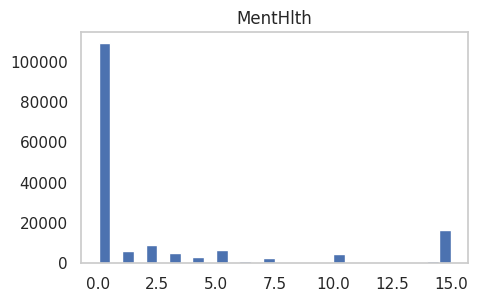

In [42]:
temp_df = ClampTransformer(upper=15).fit_transform(train_df[["MentHlth"]])
temp_df.hist(figsize=(5,3), bins=30, grid=False)
plt.show()

From this new graph, we will try to update the range to be lower than 5

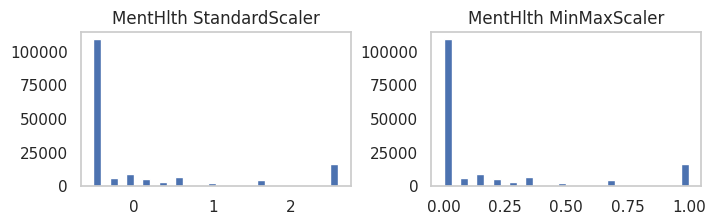

In [43]:
feature = "MentHlth"
ment_hlth_transformed = pd.DataFrame({
    f"{feature} {StandardScaler.__name__}": StandardScaler().fit_transform(temp_df).squeeze(),
    f"{feature} {MinMaxScaler.__name__}": MinMaxScaler().fit_transform(temp_df).squeeze()
})

ment_hlth_transformed.hist(figsize=(8,2), bins=30, grid=False)
plt.show()

To complete the normalization of this feature, as this feature is a scale only, we will select the `MinMaxScaler`

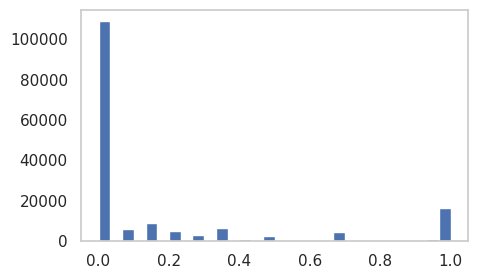

In [44]:
clamp_minmax_transformer = Pipeline([
    ("clamp", ClampTransformer(upper=15)),
    ("minmax", MinMaxScaler())
])

clamp_minmax_transformer.fit_transform(train_df[["MentHlth"]]).squeeze().hist(figsize=(5,3), bins=30, grid=False)
plt.show()

Now that we defined a theoritical transformer, we will run the validation step to see if it improves the model output.

In [45]:
temp_transformer = Pipeline([
    ("clamp", ClampTransformer(upper=15)),
    ("minmax", MinMaxScaler())
])
temp_transformer.fit(train_df[["MentHlth"]])

evaluator = PreprocessingEvaluator(
    X=val_df.drop("target", axis=1),
    y=val_df["target"],
    transformer=temp_transformer,
    column_transformed="MentHlth",
    verbose=True
)

evaluator.evaluate()
evaluator.display_comparison()

transforming dataset...
Evaluating old dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Evaluating new dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Model                Metric          Before          After           Gap            
--------------------------------------------------------------------------------
Random Forest        accuracy        0.8568          0.8558          -0.0010        
Random Forest        precision       0.4915          0.4809          -0.0106        
Random Forest        recall          0.1381          0.1438          0.0057         
Random Forest        f1_score        0.2156          0.2214          0.0058         
--------------------------------------------------------------------------------
SVM                  accuracy        0.8575          0.8575          0.0000         
SVM                  precision       0.0000          0.0000          0.0000         
SVM        

Most of the metrics shows model improvement, so we will keep this transformation for this column

#### Physical Health (PhysHlth)

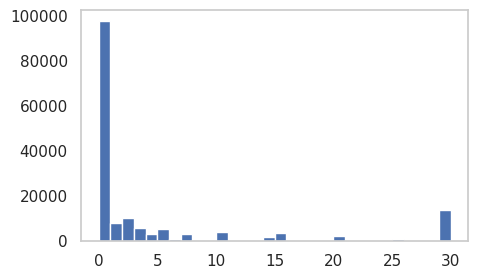

In [46]:
# Graph reminder
train_df["PhysHlth"].hist(figsize=(5,3), bins=30, grid=False)
plt.show()

The distribution of this graph is almost the same as mental health, so we will apply the same transformation chain

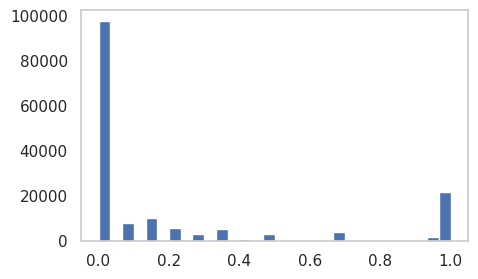

In [47]:
clamp_minmax_transformer = Pipeline([
    ("clamp", ClampTransformer(upper=15)),
    ("minmax", MinMaxScaler())
])

clamp_minmax_transformer.fit_transform(train_df[["PhysHlth"]]).squeeze().hist(figsize=(5,3), bins=30, grid=False)
plt.show()

Now that we defined a theoritical transformer, we will run the validation step to see if it improves the model output.

In [48]:
temp_transformer = Pipeline([
    ("clamp", ClampTransformer(upper=15)),
    ("minmax", MinMaxScaler())
])
temp_transformer.fit(clean_df[["PhysHlth"]])

evaluator = PreprocessingEvaluator(
    X=val_df.drop("target", axis=1),
    y=val_df["target"],
    transformer=temp_transformer,
    column_transformed="PhysHlth",
    verbose=True
)

evaluator.evaluate()
evaluator.display_comparison()

transforming dataset...
Evaluating old dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Evaluating new dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Model                Metric          Before          After           Gap            
--------------------------------------------------------------------------------
Random Forest        accuracy        0.8568          0.8565          -0.0003        
Random Forest        precision       0.4915          0.4884          -0.0031        
Random Forest        recall          0.1381          0.1410          0.0029         
Random Forest        f1_score        0.2156          0.2188          0.0032         
--------------------------------------------------------------------------------
SVM                  accuracy        0.8575          0.8575          0.0000         
SVM                  precision       0.0000          0.0000          0.0000         
SVM        

Most of the metrics shows model improvement, so we will keep this transformation for this column

#### Age

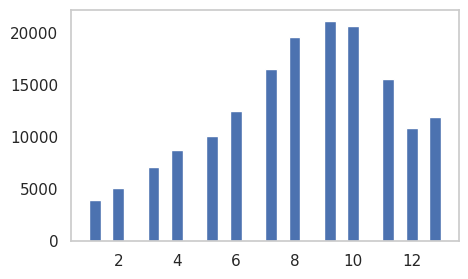

In [49]:
# Graph reminder
train_df["Age"].hist(figsize=(5,3), bins=30, grid=False)
plt.show()

This graph shows a left skewed distribution on a too wide range $[0;13]$. The main problem is that the tools we use only work on right skewed distribution, so we need to reflect this distribution using $X = \max(X) + 1 - X$ and then apply one or more transformation.

In [50]:
class ReflectTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        for col in X.columns:
            X_copy[col] = np.max(X_copy[col] + 1) - X_copy[col]
        return X_copy

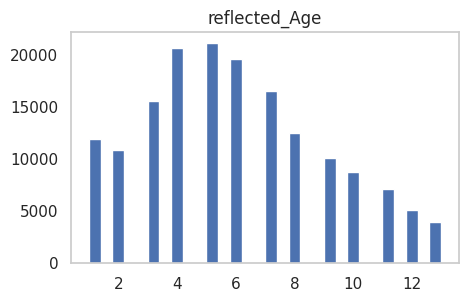

In [51]:
temp_df = ReflectTransformer().fit_transform(train_df[["Age"]])
temp_df.columns = ["reflected_Age"]
temp_df.hist(figsize=(5,3), bins=30, grid=False)
plt.show()

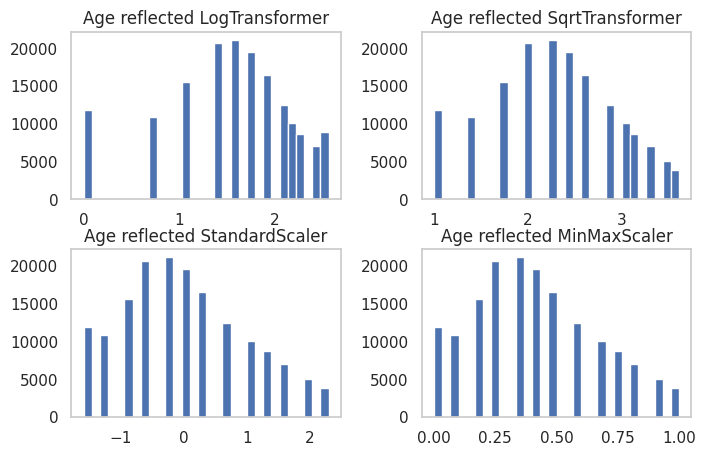

In [52]:
feature = "Age"
age_transformed = pd.DataFrame({
    f"{feature} reflected {LogTransformer().__class__.__name__}": LogTransformer().fit_transform(temp_df).squeeze(),
    f"{feature} reflected {SqrtTransformer().__class__.__name__}": SqrtTransformer().fit_transform(temp_df).squeeze(),
    f"{feature} reflected {StandardScaler().__class__.__name__}": StandardScaler().fit_transform(temp_df).squeeze(),
    f"{feature} reflected {MinMaxScaler().__class__.__name__}": MinMaxScaler().fit_transform(temp_df).squeeze()
})

age_transformed.hist(figsize=(8,5), bins=30, grid=False)
plt.show()

When applying the transformations after relfection, we can see that the `SqrtTransformer` gives the distribution that is the closest to a gaussian distribution while having a small enough range.

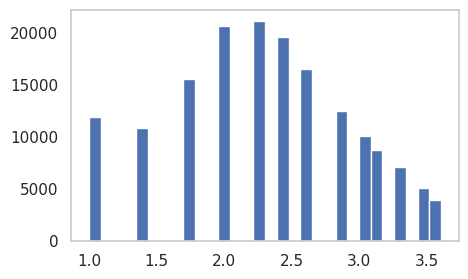

In [53]:
reflect_sqrt_transformer = Pipeline([
    ("reflect", ReflectTransformer()),
    ("sqrt", SqrtTransformer())
])

reflect_sqrt_transformer.fit_transform(train_df[["Age"]]).squeeze().hist(figsize=(5,3), bins=30, grid=False)
plt.show()

Now that we defined a theoritical transformer, we will run the validation step to see if it improves the model output.

In [54]:
temp_transformer = Pipeline([
    ("reflect", ReflectTransformer()),
    ("sqrt", SqrtTransformer())
])
temp_transformer.fit(train_df[["Age"]])

evaluator = PreprocessingEvaluator(
    X=val_df.drop("target", axis=1),
    y=val_df["target"],
    transformer=temp_transformer,
    column_transformed="Age",
    verbose=True
)

evaluator.evaluate()
evaluator.display_comparison()

transforming dataset...
Evaluating old dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Evaluating new dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Model                Metric          Before          After           Gap            
--------------------------------------------------------------------------------
Random Forest        accuracy        0.8568          0.8583          0.0015         
Random Forest        precision       0.4915          0.5099          0.0184         
Random Forest        recall          0.1381          0.1467          0.0086         
Random Forest        f1_score        0.2156          0.2278          0.0122         
--------------------------------------------------------------------------------
SVM                  accuracy        0.8575          0.8575          0.0000         
SVM                  precision       0.0000          0.0000          0.0000         
SVM        

Most of the metrics shows model improvement, so we will keep this transformation for this column

#### Education

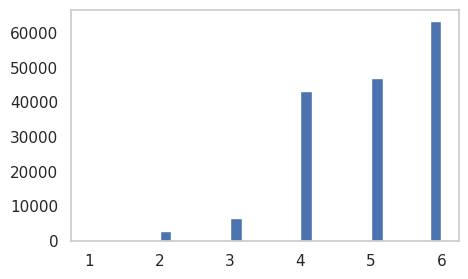

In [55]:
# Graph reminder
train_df["Education"].hist(figsize=(5,3), bins=30, grid=False)
plt.show()

By looking at this distribution graph, we can see that this feature doesn't come close to a gaussian distribution and the value range is small enough to not require normalization.

#### Income

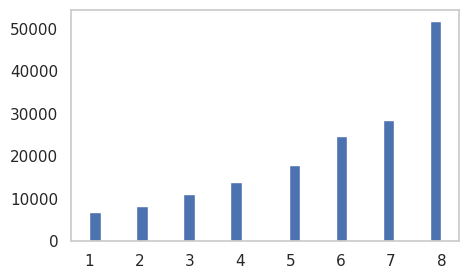

In [56]:
# Graph reminder
train_df["Income"].hist(figsize=(5,3), bins=30, grid=False)
plt.show()

On this distribution graph, we are not any close to a gaussian distribution, but the value range is a bit too wide $[1:8]$ and will benefit from `StandardScaler` or `MinMaxScaler`.

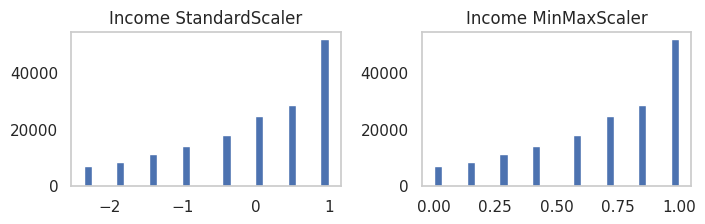

In [57]:
feature = "Income"
bmi_transformed = pd.DataFrame({
    f"{feature} {StandardScaler().__class__.__name__}": StandardScaler().fit_transform(train_df[[feature]]).squeeze(),
    f"{feature} {MinMaxScaler().__class__.__name__}": MinMaxScaler().fit_transform(train_df[[feature]]).squeeze()
})

bmi_transformed.hist(figsize=(8,2), bins=30, grid=False)
plt.show()

We can see that both transformations reduce the value range be less than 5, the main difference is about the center of the graph. As the *Income* feature is only a scale without any opposite meaning when taking the extreme values, the StandardScaler may introduce wrong biais, so we will be using `MinMaxScaler`

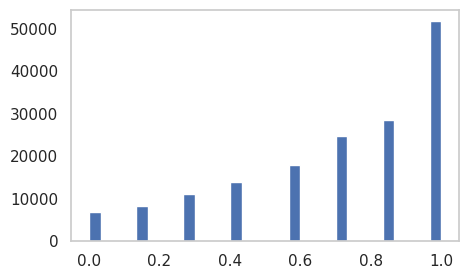

In [58]:
MinMaxScaler().fit_transform(train_df[["Income"]]).squeeze().hist(figsize=(5,3), bins=30, grid=False)
plt.show()

Now that we defined a theoritical transformer, we will run the validation step to see if it improves the model output.

In [59]:
temp_transformer = MinMaxScaler()
temp_transformer.fit(train_df[["Income"]])

evaluator = PreprocessingEvaluator(
    X=val_df.drop("target", axis=1),
    y=val_df["target"],
    transformer=temp_transformer,
    column_transformed="Income",
    verbose=True
)

evaluator.evaluate()
evaluator.display_comparison()

transforming dataset...
Evaluating old dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Evaluating new dataset...
Running Random Forest...
Running SVM...
Running KNN...
Running Naive Bayes...
Model                Metric          Before          After           Gap            
--------------------------------------------------------------------------------
Random Forest        accuracy        0.8568          0.8569          0.0001         
Random Forest        precision       0.4915          0.4932          0.0017         
Random Forest        recall          0.1381          0.1381          0.0000         
Random Forest        f1_score        0.2156          0.2158          0.0002         
--------------------------------------------------------------------------------
SVM                  accuracy        0.8575          0.8575          0.0000         
SVM                  precision       0.0000          0.0000          0.0000         
SVM        

Most of the metrics shows model improvement, so we will keep this transformation for this column

### Final normalization transformer

In [60]:
# Clamp transformer
class ClampTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, upper=None, lower=None):
        self.upper = upper
        self.lower = lower

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        for col in X.columns:
            if self.upper is not None:
                X_copy[col] = np.minimum(X_copy[col], self.upper)
            if self.lower is not None:
                X_copy[col] = np.maximum(X_copy[col], self.lower)
        return X_copy

class ReflectTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        for col in X.columns:
            X_copy[col] = np.max(X_copy[col] + 1) - X_copy[col]
        return X_copy

log_minmax_transformer = Pipeline([
    ("log", LogTransformer()),
    ("minmax", MinMaxScaler())
])

clamp_minmax_transformer = Pipeline([
    ("clamp", ClampTransformer(upper=15)),
    ("minmax", MinMaxScaler())
])

reflect_sqrt_transformer = Pipeline([
    ("reflect", ReflectTransformer()),
    ("sqrt", SqrtTransformer())
])

non_transformed_features = binary_vars + ["Education"] + ["target"]

normalization_transformer = ColumnTransformer([
    ("log_minmax", log_minmax_transformer, ["BMI"]),
    ("minmax", MinMaxScaler(), ["Income"]),
    ("clamp", clamp_minmax_transformer, ["MentHlth", "PhysHlth"]),
    ("reflect_sqrt", reflect_sqrt_transformer, ["Age"]),
    ("std", StandardScaler(), ["GenHlth"]),
    ("none", "passthrough", non_transformed_features)
], verbose_feature_names_out=False)

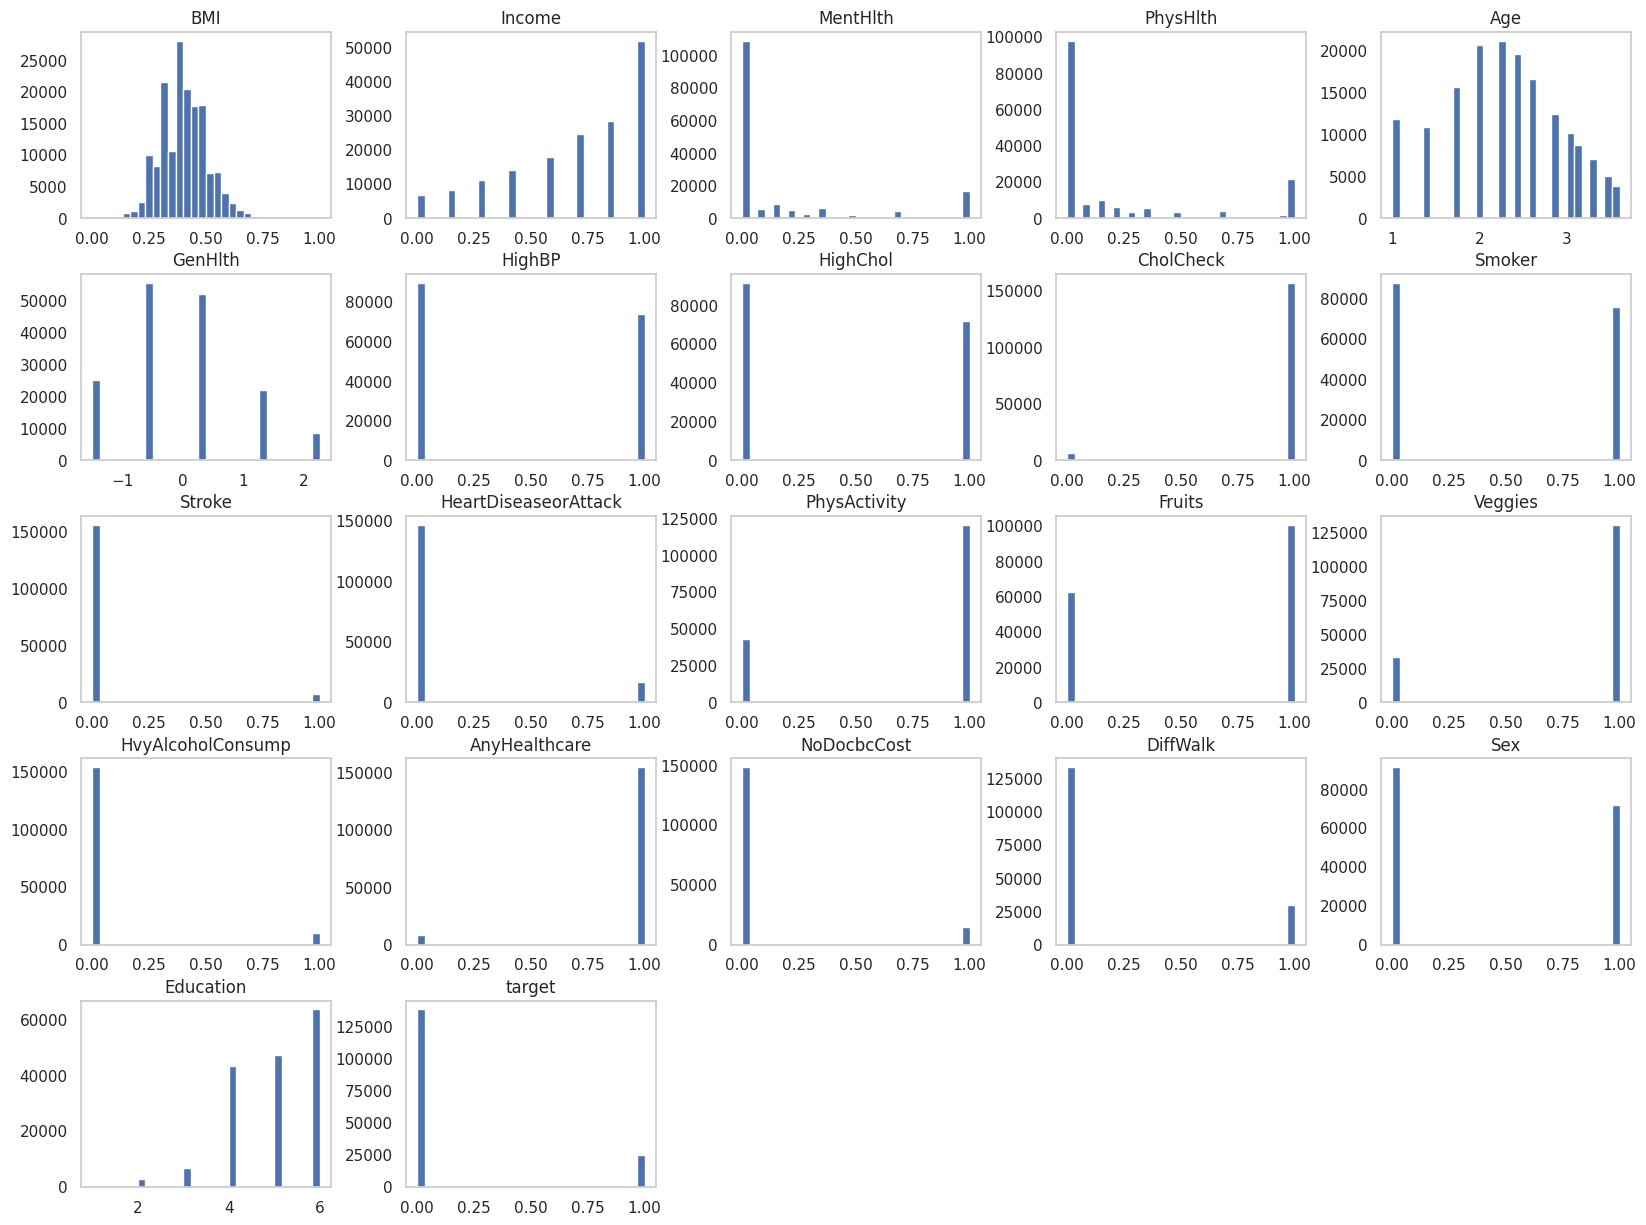

In [61]:
normalized_df = normalization_transformer.fit_transform(train_df)
normalized_df.hist(figsize=(20,15), bins=30, grid=False)
plt.show()

## 9. Pipeline Transformation algorithm (MLOps)

In [62]:
# Clamp transformer
class ClampTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, upper=None, lower=None):
        self.upper = upper
        self.lower = lower

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        for col in X.columns:
            if self.upper is not None:
                X_copy[col] = np.minimum(X_copy[col], self.upper)
            if self.lower is not None:
                X_copy[col] = np.maximum(X_copy[col], self.lower)
        return X_copy

class ReflectTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        for col in X.columns:
            X_copy[col] = np.max(X_copy[col] + 1) - X_copy[col]
        return X_copy

class DeduplicationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        return X.drop_duplicates()

class MissingValueImputationTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strategy="drop"):
        self.strategy = strategy

    def fit(self, X, y=None):
        if self.strategy == "median":
            self.fill_values_ = X.median()
        elif self.strategy == "mean":
            self.fill_values_ = X.mean()
        elif self.strategy == "most_frequent":
            self.fill_values_ = X.mode().iloc[0]
        elif self.strategy == "drop":
            self.fill_values_ = None
        else:
            raise ValueError("Invalid strategy. Use 'median', 'mean', or 'most_frequent'.")
        return self

    def transform(self, X):
        check_is_fitted(self)
        if self.fill_values_ is None:
            return X.dropna()
        return X.fillna(self.fill_values_)

class DiabetesTargetBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, column_name="Diabetes_012", output_column_name="target", drop_original=True):
        self.column_name = column_name
        self.output_column_name = output_column_name
        self.drop_original = drop_original

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        X_copy = X.copy()
        X_copy[self.output_column_name] = X_copy[self.column_name].apply(lambda x: 1 if x == 2 else 0)
        if self.drop_original:
            X_copy = X_copy.drop(self.column_name, axis=1)
        return X_copy

class StratifiedSplitter(BaseEstimator, TransformerMixin):
    def __init__(self, test_size=0.3, val_size=0.5, y_column_name=None, random_state=None):
        self.test_size = test_size
        self.val_size = val_size
        self.y_column_name = y_column_name
        self.random_state = random_state

    def __sklearn_is_fitted__(self):
        # This method is required by scikit-learn to check if the transformer is fitted
        return True

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        check_is_fitted(self)
        y = X[self.y_column_name] if self.y_column_name else None
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y,
            test_size=self.test_size,
            stratify=y,
            random_state=self.random_state
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp,
            test_size=self.val_size,
            stratify=y_temp,
            random_state=self.random_state
        )
        return (X_train, y_train), (X_val, y_val), (X_test, y_test)

log_minmax_transformer = Pipeline([
    ("log", LogTransformer()),
    ("minmax", MinMaxScaler())
])

clamp_minmax_transformer = Pipeline([
    ("clamp", ClampTransformer(upper=15)),
    ("minmax", MinMaxScaler())
])

reflect_sqrt_transformer = Pipeline([
    ("reflect", ReflectTransformer()),
    ("sqrt", SqrtTransformer())
])

non_transformed_features = binary_vars + ["Education"] + ["target"]

normalization_transformer = ColumnTransformer([
    ("log_minmax", log_minmax_transformer, ["BMI"]),
    ("minmax", MinMaxScaler(), ["Income"]),
    ("clamp", clamp_minmax_transformer, ["MentHlth", "PhysHlth"]),
    ("reflect_sqrt", reflect_sqrt_transformer, ["Age"]),
    ("std", StandardScaler(), ["GenHlth"]),
    ("none", "passthrough", non_transformed_features)
], verbose_feature_names_out=False)

diabetes_binarizer = DiabetesTargetBinarizer(column_name="Diabetes_012", output_column_name="target", drop_original=True)

stratified_splitter = StratifiedSplitter(test_size=0.15, val_size=0.15, random_state=SEED, y_column_name="target")

data_transformation_pipeline = Pipeline([
    ("missing_imputation", MissingValueImputationTransformer(strategy="drop")),
    ("deduplication", DeduplicationTransformer()),
    ("normalization", normalization_transformer),
])

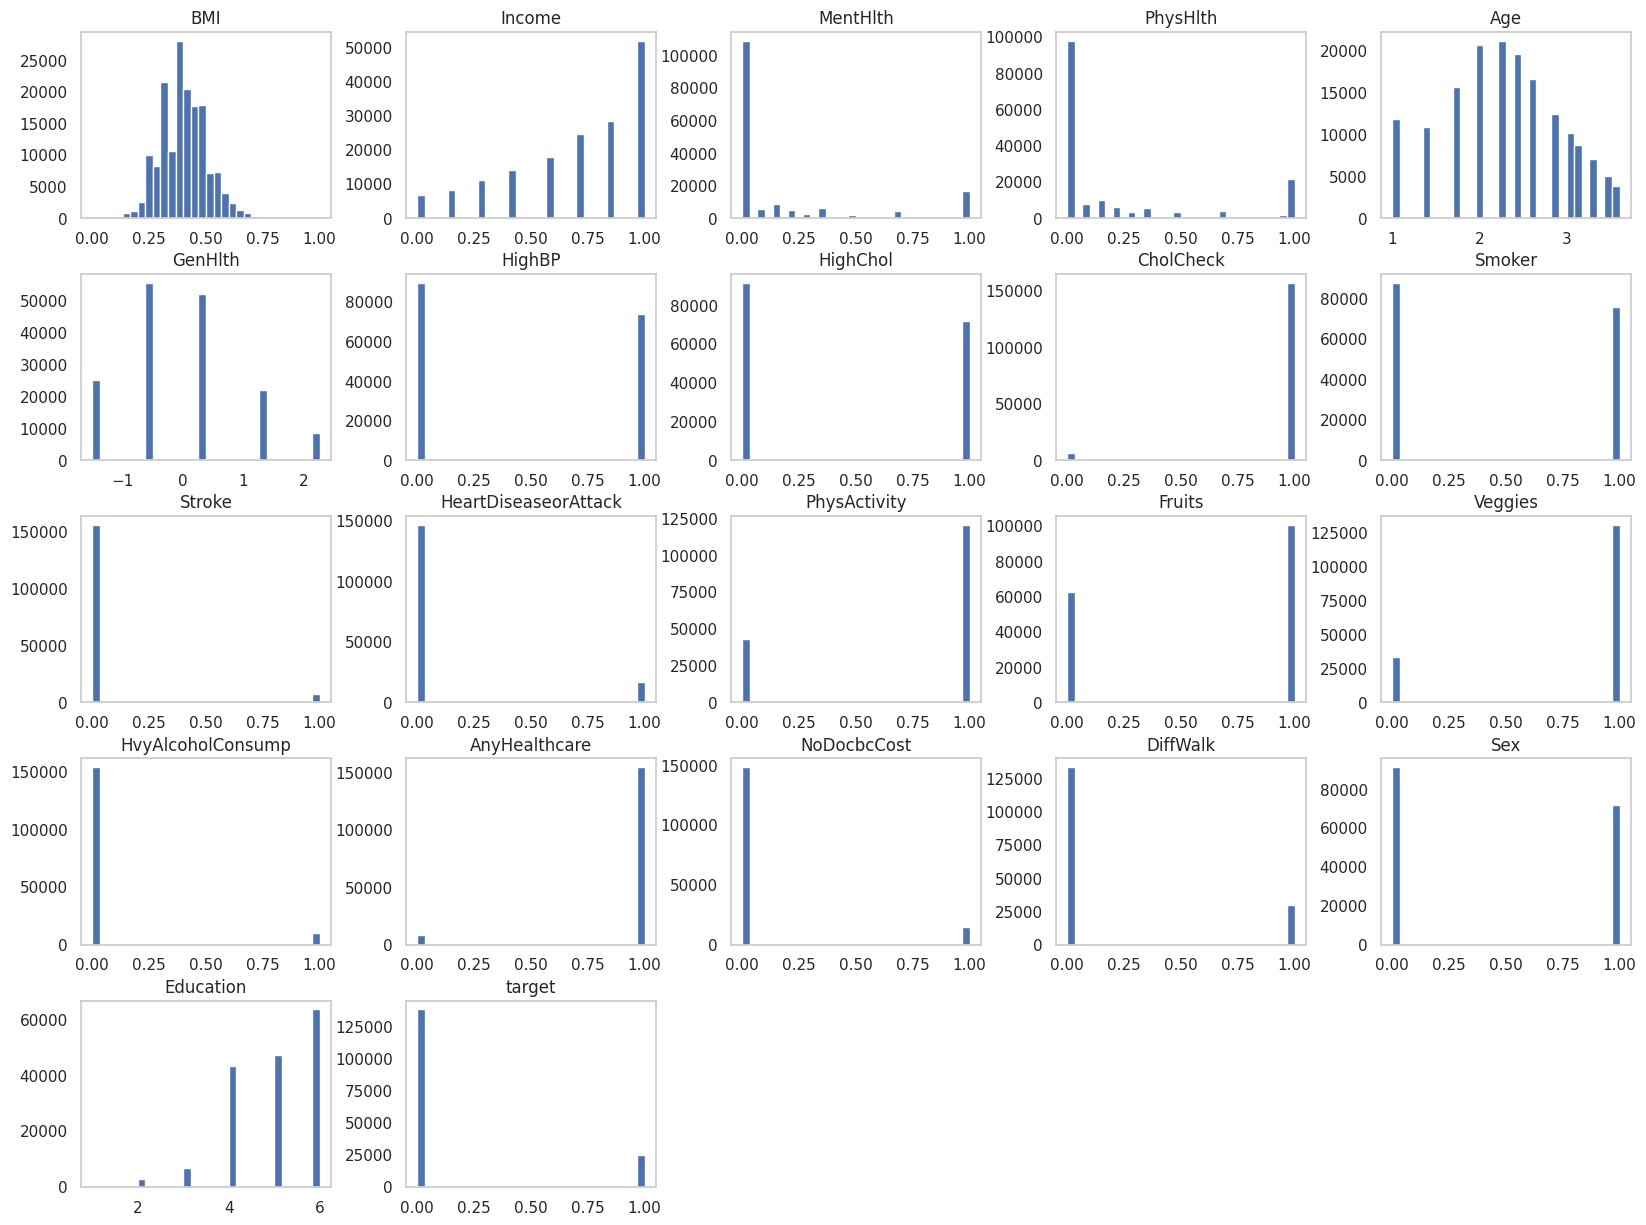

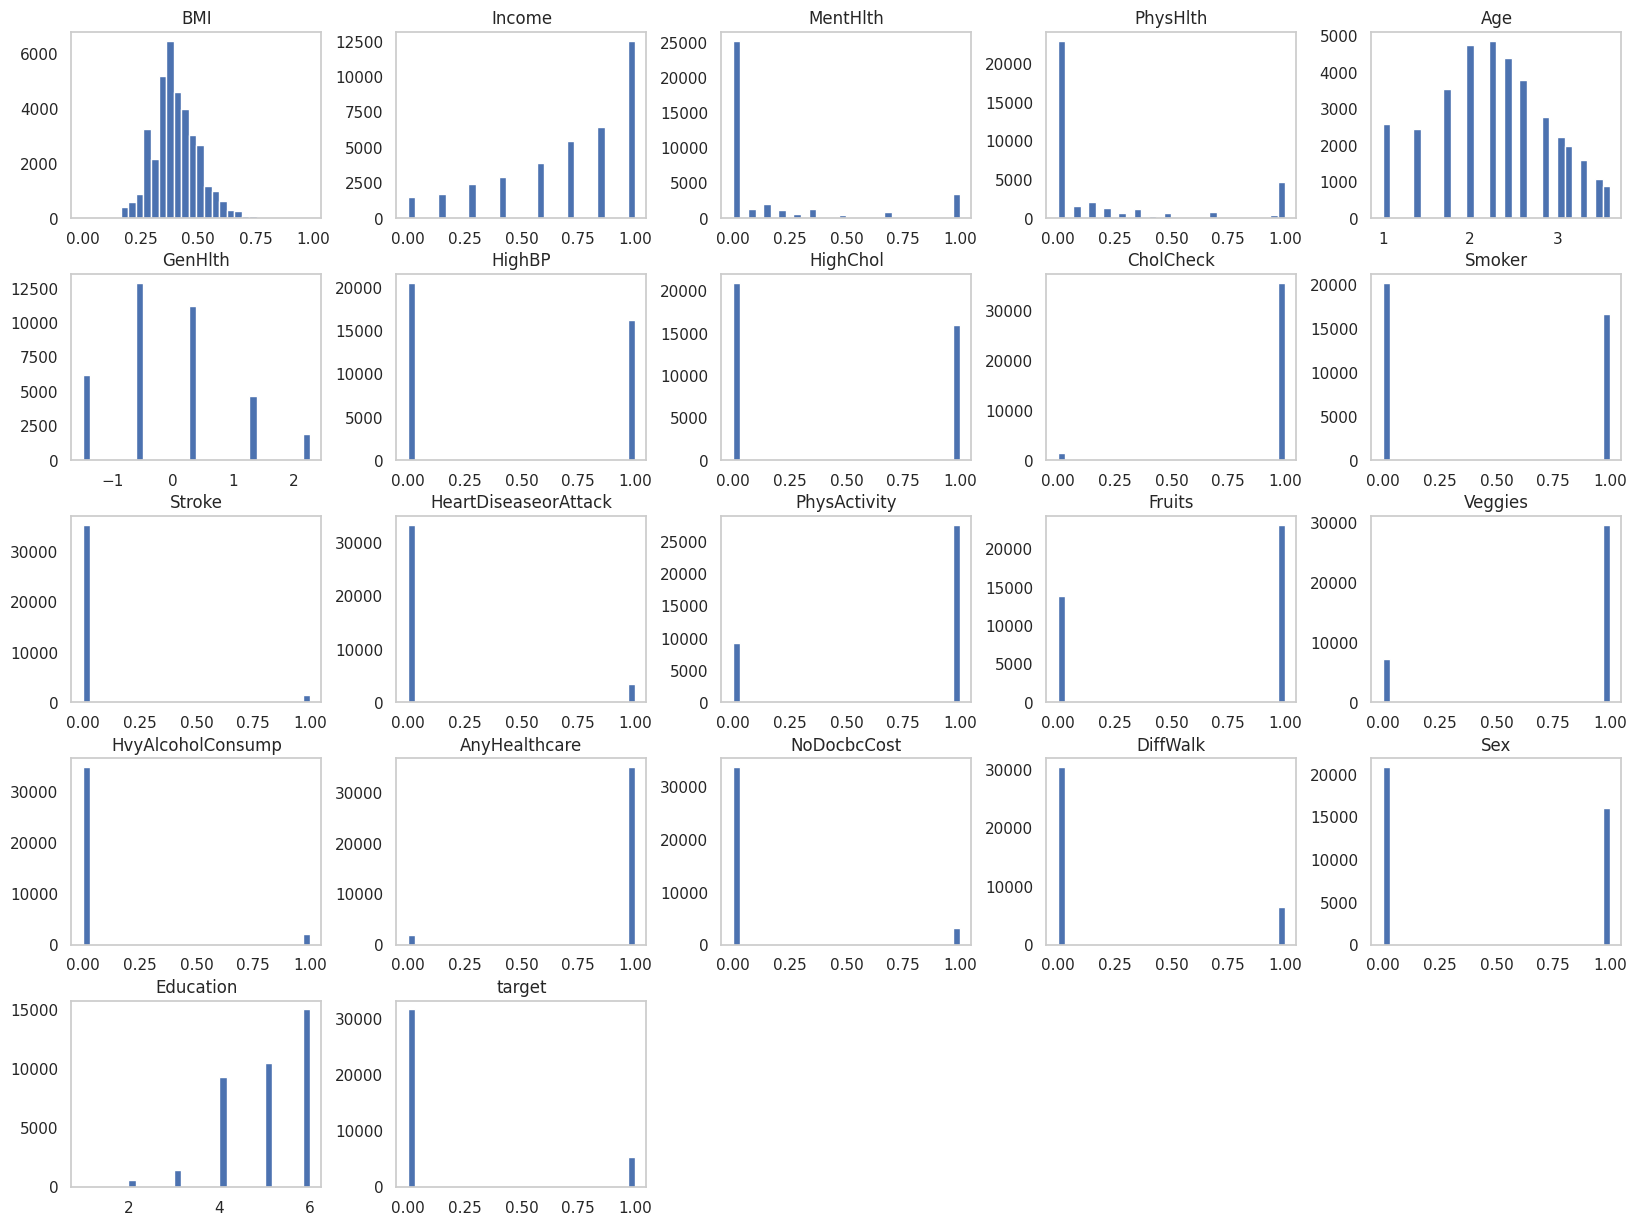

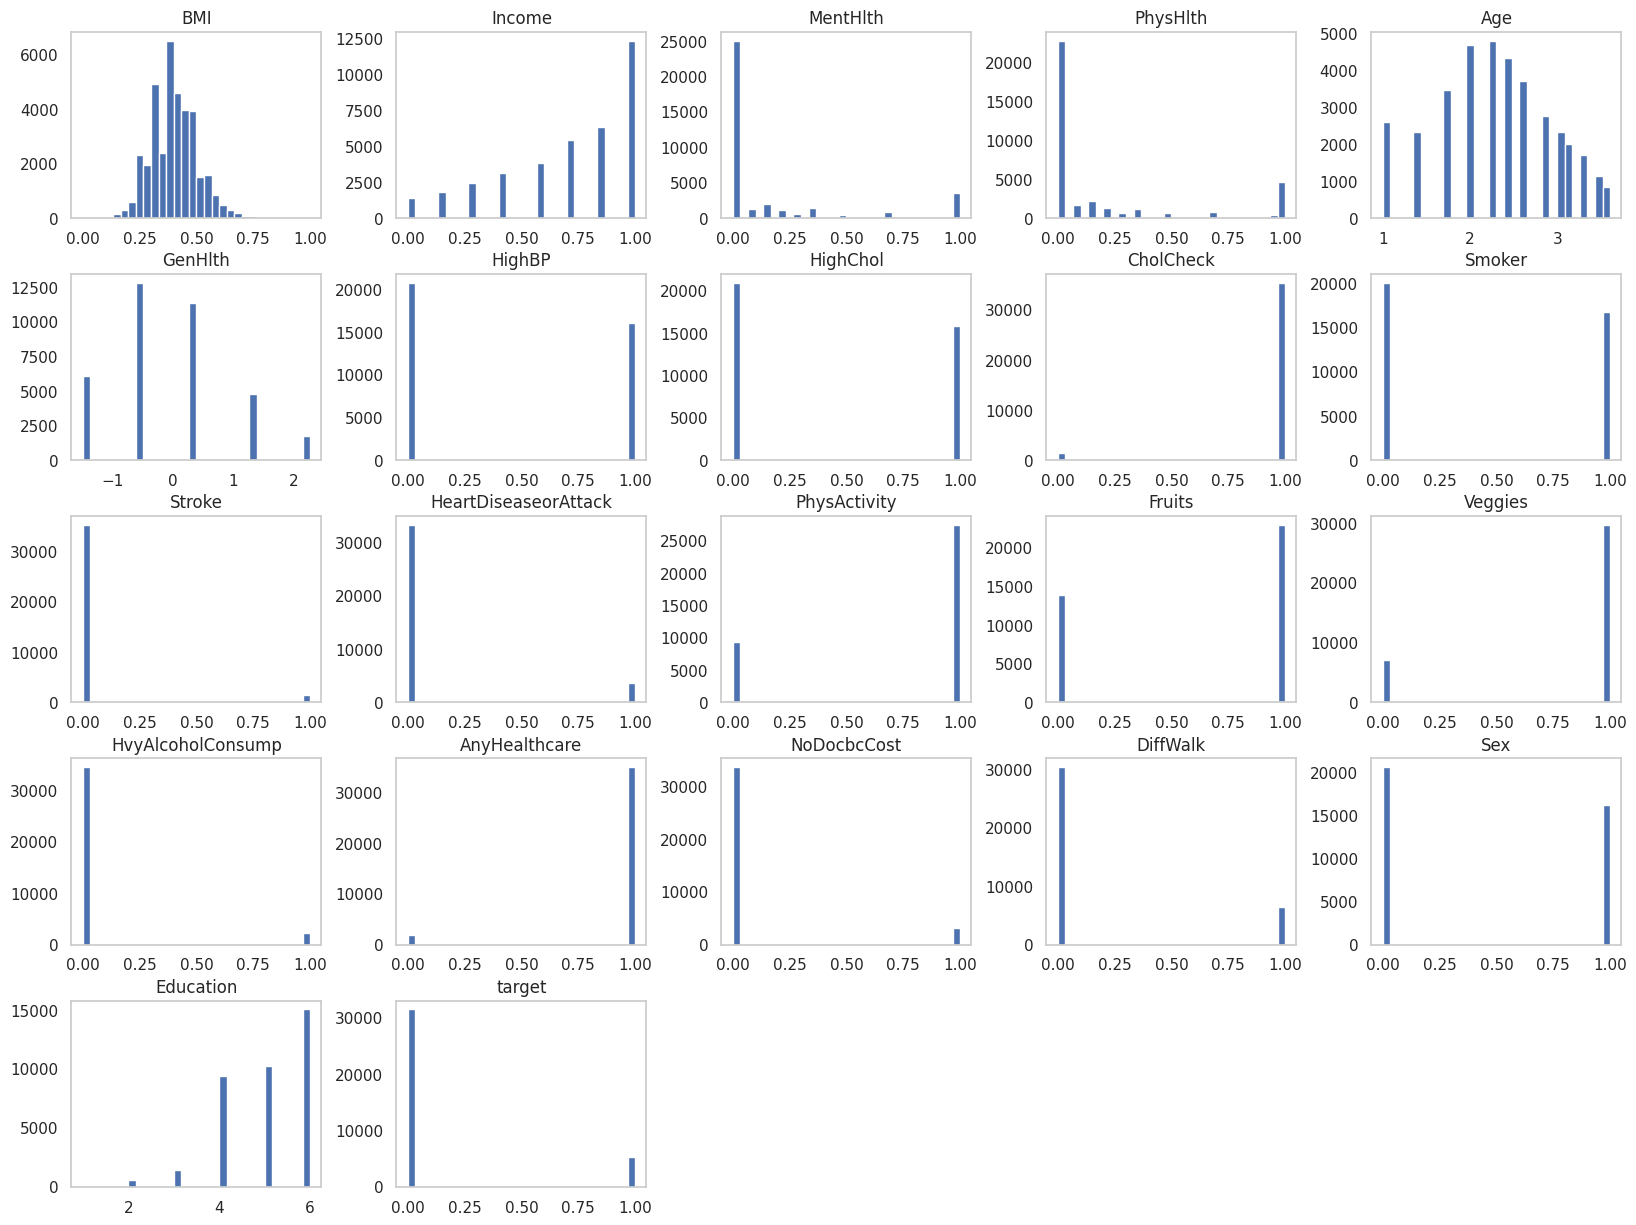

In [63]:
diabete_binary_df = diabetes_binarizer.fit_transform(raw_df)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = stratified_splitter.fit_transform(diabete_binary_df)


train_df = data_transformation_pipeline.fit_transform(train_df)
val_df = data_transformation_pipeline.transform(val_df)
test_df = data_transformation_pipeline.transform(test_df)
train_df.hist(figsize=(20,15), bins=30, grid=False)
val_df.hist(figsize=(20,15), bins=30, grid=False)
test_df.hist(figsize=(20,15), bins=30, grid=False)
plt.show()

## 10. Saving of the cleaned dataset

To complete this document, we will now save the cleaned dataset into multiple CSV files

In [64]:
# Save to CSV files
train_path = OUTPUT_DIR / "train_data.csv"
val_path = OUTPUT_DIR / "validation_data.csv"
test_path = OUTPUT_DIR / "test_data.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Training data saved to: {train_path}")
print(f"Validation data saved to: {val_path}")
print(f"Test data saved to: {test_path}")
print()
print(f"Training set: {train_df.shape[0]} samples, {train_df.shape[1]} features")
print(f"Validation set: {val_df.shape[0]} samples, {val_df.shape[1]} features")
print(f"Test set: {test_df.shape[0]} samples, {test_df.shape[1]} features")

Training data saved to: deliverables/train_data.csv
Validation data saved to: deliverables/validation_data.csv
Test data saved to: deliverables/test_data.csv

Training set: 163185 samples, 22 features
Validation set: 36828 samples, 22 features
Test set: 36806 samples, 22 features


## Glossary of variables

In [65]:
# Raw loaded data
raw_df: pd.DataFrame
# Temporary dataframe used for testing transformations (to be reset before each transformation test)
temp_df: pd.DataFrame
# Training set after splitting
train_df: pd.DataFrame
# Validation set after splitting
val_df: pd.DataFrame
# Test set after splitting
test_df: pd.DataFrame

# Variable types
binary_vars: list[str]
ordinal_or_categorical_vars: list[str]
quantitative_vars: list[str]

# Input and output variables
# Full input features and target
X: pd.DataFrame
y: pd.Series
# Training set features and target
X_train: pd.DataFrame
y_train: pd.Series
# Validation set features and target
X_val: pd.DataFrame
y_val: pd.Series
# Test set features and target
X_test: pd.DataFrame
y_test: pd.Series

# Columns that should not be transformed (e.g., binary variables)
non_transformed_features: list[str]

# Data transformation pipeline
# A combination of LogTransformer then MinMaxScaler
log_minmax_transformer: Pipeline
# A combination of ClampTransformer then MinMaxScaler
clamp_minmax_transformer: Pipeline
# A combination of ReflectTransformer then SqrtTransformer
reflect_sqrt_transformer: Pipeline
# Applies all the transformations to the dataset
normalization_transformer: ColumnTransformer
# Temp transformer used for testing individual transformations
temp_transformer: BaseEstimator